
FEATURE ENGINEERING ____ POLYMARKET TIMESERIES BUILDER
(PLS + LASSO DIMENSIONALITY REDUCTION VARIANT)

Run cells top-to-bottom. Only the CONFIG cell requires manual input.

This notebook is a variant of "Feature Engineering SQL polymarket database.ipynb".
It replaces the SFS (market selection) and RFE (variable selection) stages with a
three-stage pipeline:

**Stage 1 — Market filters (before any dimensionality reduction)**
  1a. Span / edge filter: keep markets covering ≥ MARKET_MIN_SPAN_RATIO of the sample.
  1b. Missingness filter: drop variables with overall NaN rate > MISSINGNESS_FILTER_THRESHOLD.
  1c. Manual exclusion list: drop non-relevant markets (APPLY_MANUAL_MARKET_FILTER).
  1d. F-statistic market filter: rank remaining markets by OLS F-statistic vs the gold
      target; retain the top FSTAT_TOP_K_MARKETS (APPLY_FSTAT_MARKET_FILTER).

**Stage 2 — Variable filters**
  2a. Near-zero-variance drop.
  2b. Stationarity transformation (log-diff or first-diff for non-stationary series).

**Stage 3 — Exports**
  3a. PRIMARY EXPORT: `polymarket_panel_filtered_<TIMESTAMP>.csv` — the filtered raw
      panel (wide, flat-column, aligned to the Bloomberg 5-min grid). This is the file
      Modelling Baseline reads. PLS/Lasso are re-fit inside each walk-forward window.
  3b. PRIMARY EXPORT: `bloomberg_panel_stationary_<TIMESTAMP>.csv` — Bloomberg
      traditional predictors on the 5-min gold grid, with test-driven stationarity
      transforms and staleness counters applied upstream.
  3c. AUDIT EXPORT: `bloomberg_stationarity_metadata_<TIMESTAMP>.json` — stationarity
      decisions, transforms, and ADF/KPSS p-values used to build the Bloomberg panel.
  3d. DESCRIPTIVE ONLY: `df_pls_descriptive_<TIMESTAMP>.csv` — PLS components fit on the
      full sample. For research inspection only; NOT for backtesting.
  3e. DESCRIPTIVE ONLY: `df_lasso_descriptive_<TIMESTAMP>.csv` — Lasso-selected features
      fit on the full sample. For research inspection only; NOT for backtesting.

AR features are excluded from the exported feature panels and handled in Modelling Baseline.



#### 0. Config

In [1]:

# %% ── CELL 0 : CONFIG ───────────────────────────────────────────────────────
from pathlib import Path

# Folders
DATA_DIR     = Path("./Data")
MODELS_DIR   = Path("./Models")
RESULTS_DIR  = Path("./Results")
for p in (MODELS_DIR, RESULTS_DIR):
    p.mkdir(exist_ok=True, parents=True)

# File patterns
GOLD_PANEL_GLOB = "gold_panel_*.csv"          # dynamic date in file name
BLOOMBERG_XLSX_CANDIDATES = [
    DATA_DIR / "Indicators Data bloomberg.xlsx",
    DATA_DIR / "Indicators-Data-bloomberg.xlsx",
    DATA_DIR / "Indicators_Data_bloomberg.xlsx",
]
TARGET_SHEET    = "GOLD USD SPOT PER OZ"
TARGET_COL      = "Close"

def resolve_bloomberg_xlsx(candidates: list[Path], data_dir: Path) -> Path:
    for p in candidates:
        if p.exists():
            return p
    # Fallback: pick any workbook that looks like the indicators file
    wildcard = sorted(data_dir.glob("*Indicators*Data*bloomberg*.xlsx"))
    if wildcard:
        return wildcard[0]
    tried = "\n  - ".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "Bloomberg workbook not found. Tried:\n"
        f"  - {tried}\n"
        "Expected something like 'Indicators Data bloomberg.xlsx' in ./Data."
    )

BLOOMBERG_XLSX = resolve_bloomberg_xlsx(BLOOMBERG_XLSX_CANDIDATES, DATA_DIR)
print(f"Using Bloomberg workbook: {BLOOMBERG_XLSX}")

# ─── Modelling ───────────────────────────────────────────────────────────────
BAR_MINUTES         = 5          # native cadence of the Bloomberg close series
RETURN_HORIZON_MIN  = 60         # ⟵ target-return horizon in MINUTES.
                                 #    60   -> 1-hour returns (current default)
                                 #    240  -> 4-hour returns (to test next)
                                 #    1440 -> next-day returns (to test later)
                                 #    5    -> old 5-min behaviour
HORIZON_STEPS       = max(1, RETURN_HORIZON_MIN // BAR_MINUTES)  # #bars ahead predicted
AR_LAGS             = [1, 2, 3, 6, 12]       # past-return lags (in 5-min bars)
AR_MA_WINDOWS       = [3, 6, 12, 36]         # rolling-mean windows on past returns
WINDOW_SCHEMES  = {                          # {label: ("fixed"|"expanding", size)}
    "fixed120":  ("fixed", 120),
    "fixed240":  ("fixed", 240),
    "fixed300":  ("fixed", 300),
    "expanding": ("expanding", 120),         # 120 = minimum training size before first prediction
}
LSTM_TEST_BLOCK = 12           # LSTM retrain cadence — predict next 12 obs per refit
LSTM_SEQ_LEN    = 12           # look-back length fed into the LSTM (≈ 1 hour)
LSTM_EPOCHS     = 8
LSTM_BATCH      = 32
RF_N_ESTIMATORS = 200
RANDOM_STATE    = 67

# ─── Regularisation knobs (tunable from here for quick iteration) ────────────
# Ridge penalty. Start around 10–100 when Polymarket features are still raw-ish;
# drop to ~1.0 once proper feature engineering / selection has been done.
RIDGE_ALPHA     = 10.0

# PCA pre-compression applied to the Polymarket block ONLY (AR features are
# kept raw, they are already in return-space and low-dim).
# Set PCA_N_COMPONENTS = 0 (or None) to disable PCA entirely.
#   typical range: 20–40 while Polymarket dim is high;
#   after feature engineering you can probably drop it to 0.
PCA_N_COMPONENTS = 30

# ─── Traditional indicators — separate PCA and feature engineering controls ──
# Independent PCA for the Bloomberg traditional block: typically 3–8 components
# (one per macro factor: rates, equities, FX, commodities, vol, etc.).
# Set to 0 to disable PCA on the traditional block entirely.
PCA_N_COMPONENTS_TRADITIONAL = 5

# Forward-fill cap when resampling daily Bloomberg indicators to the 5-min gold
# clock.  None = carry indefinitely (standard for Bloomberg daily data);
# set an integer to cap stale carries (e.g., 288 = ~1 trading day on a 5-min grid).
TRADITIONAL_MAX_FFILL_BARS   = None

# Add a staleness counter feature for each traditional indicator:
# tells the model how many 5-min bars have elapsed since the last real tick.
# Useful because daily series are stale for ~288 bars between updates.
TRADITIONAL_USE_STALENESS    = True

# Drop raw price-level columns after stationarising (default True).
# They are collinear with the diff/log-return columns and can confuse Ridge.
TRADITIONAL_DROP_PRICE_LEVELS = True

# AR features of the gold log-return appended to the traditional predictor matrix.
# Must mirror the full AR feature set used for the polymarket block so that both
# sets of models see the same autoregressive information:
#   - 5 lagged returns  (AR_LAGS)
#   - 4 rolling means   (AR_MA_WINDOWS)
#   - 2 rolling stds    ([12, 36])
# These are passed separately to build_X_traditional via ar_lags / ar_ma_windows /
# ar_vol_windows; keeping them as explicit config allows independent tuning later.
TRADITIONAL_AR_LAGS       = [1, 2, 3, 6, 12]   # must match AR_LAGS
# ar_ma_windows and ar_vol_windows for the trad block are passed as AR_MA_WINDOWS
# and [12, 36] directly in Cell 5 (they share the same config as the poly block).

# ─── Feature engineering checkmark (variance prefilter gate) ─────────────────
# NOTE: the variance pre-filter in Cell 4.1 is a stop-gap that keeps LSTM/Ridge
# tractable while Polymarket features are still raw and high-dimensional. Once
# proper feature engineering AND selection have been done upstream (on the
# polymarket panel), the prefilter is no longer needed and can be skipped:
#   - FEATURE_ENGINEERING_DONE = False  -> prefilter ON  (keep top-N by variance)
#   - FEATURE_ENGINEERING_DONE = True   -> prefilter OFF (use all columns)
FEATURE_ENGINEERING_DONE = False

MAX_FEATURES_PREFILTER = 150   # crude variance prefilter (only used if FE not done)

# ─── Missingness controls ─────────────────────────────────────────────────────
MISSINGNESS_FILTER_THRESHOLD = 0.15   # drop variables above this overall missingness

# ─── Market coverage controls ─────────────────────────────────────────────────
# Keep markets that span most of the sample, but allow modest edge gaps instead
# of requiring exact first/last timestamp equality.
MARKET_MIN_SPAN_RATIO      = 0.85
MARKET_EDGE_TOLERANCE_BARS = 12

# Toggle for manual exclusion of non-relevant markets.
# True  -> apply the manual non_relevant_markets drop list.
# False -> keep all markets and skip manual dropping.
APPLY_MANUAL_MARKET_FILTER = True

# ─── F-statistic market filter ────────────────────────────────────────────────
# Ranks retained markets by OLS F-statistic (joint significance of all
# Polymarket variables for that market against the gold log-return target).
# Applied after span, missingness, and manual exclusion filters.
APPLY_FSTAT_MARKET_FILTER   = True
FSTAT_TOP_K_MARKETS         = 30    # keep the top-K markets by F-statistic
FSTAT_MIN_OBS_PER_MARKET    = 200   # skip market if fewer valid rows remain

# ─── CV controls (shared by PLS and Lasso tuning) ─────────────────────────────
# These mirror the walk-forward structure from Modelling Baseline:
#   - CV_N_SPLITS expanding-window folds, gap clears the prediction horizon.
#   - CV_GAP_BARS must be >= HORIZON_STEPS to prevent target leakage.
#   - CV_MAX_TRAIN_SIZE = None gives a fully expanding window (same as the
#     baseline's "expanding" scheme).
CV_N_SPLITS       = 5          # number of time-series CV folds
CV_GAP_BARS       = 24         # 24 × 5min = 2h gap — clears autocorrelation lag
CV_MAX_TRAIN_SIZE = None       # None = expanding window (sees full history)

# ─── PLS tuning ───────────────────────────────────────────────────────────────
# Grid of n_components candidates for PLSRegression.
# Applied to Polymarket predictors only — AR features are excluded from PLS
# and handled separately in Modelling Baseline.
PLS_N_COMPONENTS_GRID = list(range(1, 21))   # candidates: 1 to 20

# ─── Lasso tuning ─────────────────────────────────────────────────────────────
# Grid of regularisation strengths for sklearn Lasso.
# Lasso outputs a reduced ORIGINAL-feature dataset (non-zero coefficient columns).
# Tuned with the same walk-forward CV as PLS.
LASSO_ALPHA_GRID = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# ─── Daily gap handling (Bloomberg ~23:00 break) ─────────────────────────────
# Adds an `is_post_break` dummy AND a `poly_movement_during_break` feature
# (approach 2 + 3 combined — see the PDF diagnosis). Turn off to revert.
HANDLE_DAILY_GAP = True
GAP_THRESHOLD    = "60min"       # a bar-to-bar step > this counts as a session break

# Evaluation toggles
FORCE_RETRAIN   = False        # set True to ignore cached models
DRY_RUN_ROWS    = None         # e.g. 1000 to debug on a slice; None = full



Using Bloomberg workbook: Data\Indicators Data bloomberg.xlsx


#### Polymarket — Timeseries Dataset Builder
This notebook:
1. Downloads the **latest SQLite backup** from S3 (skips if already local)
2. Checks if a matching **timeseries CSV** already exists in `./Data/`
3. If not, **pivots the raw markets table** into a wide timeseries (rows = scraped_at, columns = MultiIndex[variable, question])
4. Runs a **sanity check** on the resulting dataframe


In [2]:
# %% ── CELL 1 : CONFIG ────────────────────────────────────────────────────────
import os

BUCKET_NAME     = "thesis-data-ab3rnhard"
S3_PREFIX       = "backups/"
LOCAL_DATA_DIR  = "./Data"
TABLE_NAME      = "markets"
SCRAPED_AT_COL  = "scraped_at"
QUESTION_COL    = "question"

BUCKET_FETCHING = True  # False to skip S3 fetching and use local files only

# Columns to DROP before pivoting (identifiers / near-100%-null / pure metadata)
# Add or remove entries here to control which variables end up in the timeseries.
COLS_TO_DROP = [
    "id",                    # row identifier, not a timeseries variable
    "conditionId",           # static identifier
    "slug",                  # static identifier
    "questionID",            # static identifier
    "clobTokenIds",          # static identifier
    "icon", "image",         # URL strings
    "description",           # long text
    "resolutionSource",      # text URL
    # "outcomes",              # JSON text
    # "outcomePrices",         # JSON text (parsed separately if needed)
    "events",                # JSON text
    "umaResolutionStatuses", # JSON text
    "submitted_by",          # text
    "marketMakerAddress",    # 100 % null
    "seriesColor",           # 100 % null
    "liquidityAmm",          # 100 % null
    "oneYearPriceChange",    # 100 % null
    "volume1moAmm",          # 100 % null
    "volume1wkAmm",          # 100 % null
    "volume1yrAmm",          # 100 % null
    "volume24hrAmm",         # 100 % null
    "volumeAmm",             # 100 % null
    "umaResolutionStatus",   # 99 % null
    "negRiskMarketID",       # json files that are still ID or irrelevant after parsing
    "negRiskRequestID",      # json files that are still ID or irrelevant after parsing
    "resolvedBy"             # json files that are still ID or irrelevant after parsing
]

# AWS credentials — read from environment variables (same pattern as Health Check)
AWS_ACCESS_KEY_ID     = (os.getenv("AWS_ACCESS_KEY_ID")     or "").strip()
AWS_SECRET_ACCESS_KEY = (os.getenv("AWS_SECRET_ACCESS_KEY") or "").strip()
AWS_REGION            = (os.getenv("AWS_REGION")            or "eu-north-1").strip() or "eu-north-1"

print("✅ Config loaded.")


✅ Config loaded.


In [3]:
# %% ── CELL 2 : DEPENDENCIES ─────────────────────────────────────────────────
try:
    import boto3
except ModuleNotFoundError:
    %pip install boto3 -q
    import boto3

import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from botocore.exceptions import ClientError

print("✅ Dependencies ready.")



✅ Dependencies ready.


In [4]:
# %% ── CELL 3 : FETCH LATEST DB FROM S3 OR USE LATEST LOCAL ─────────────────
if not BUCKET_FETCHING:
    # ── find the latest local SQLite backup ──────────────────────────────────
    local_dbs = sorted(Path(LOCAL_DATA_DIR).glob("local_database_*.sqlite"))
    if not local_dbs:
        raise FileNotFoundError(
            f"No local SQLite databases found in {LOCAL_DATA_DIR}. "
            "Set BUCKET_FETCHING=True to download from S3, or place a "
            "'local_database_YYYY-MM-DD.sqlite' file in that folder."
        )
    local_path = local_dbs[-1]          # glob sorts lexicographically → latest date last
    file_date  = local_path.stem.replace("local_database_", "")
    print(f"⏭  Bucket fetching disabled — using latest local DB:")
    print(f"   {local_path}  (date: {file_date})")
else:
    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

    missing_vars = [v for v, val in [
        ("AWS_ACCESS_KEY_ID",     AWS_ACCESS_KEY_ID),
        ("AWS_SECRET_ACCESS_KEY", AWS_SECRET_ACCESS_KEY),
    ] if not val]

    if missing_vars:
        raise ValueError(
            "Missing AWS env variable(s): " + ", ".join(missing_vars)
            + ". Set them and restart the kernel."
        )

    s3 = boto3.client(
        "s3",
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
        region_name=AWS_REGION,
    )

    # ── identify the latest backup on S3 ─────────────────────────────────────
    try:
        response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=S3_PREFIX)
    except ClientError as e:
        code = e.response.get("Error", {}).get("Code", "Unknown")
        raise RuntimeError(f"S3 request failed ({code}). Check credentials / bucket.") from e

    objects = response.get("Contents", [])
    if not objects:
        raise FileNotFoundError(f"No objects found in s3://{BUCKET_NAME}/{S3_PREFIX}")

    latest_obj  = sorted(objects, key=lambda x: x["LastModified"], reverse=True)[0]
    s3_key      = latest_obj["Key"]
    file_date   = latest_obj["LastModified"].strftime("%Y-%m-%d")
    local_name  = f"local_database_{file_date}.sqlite"
    local_path  = Path(LOCAL_DATA_DIR) / local_name

    print(f"Latest S3 object  : {s3_key}")
    print(f"Last modified     : {latest_obj['LastModified']}")
    print(f"Size              : {latest_obj['Size'] / 1024:.1f} KB")
    print(f"Expected local    : {local_path}")

    # ── download only if not already present ─────────────────────────────────
    if local_path.exists():
        print(f"\n⏭  DB already present locally — skipping download.")
    else:
        print(f"\n⬇  Downloading …")
        s3.download_file(BUCKET_NAME, s3_key, str(local_path))
        print("✅ Download complete.")


Latest S3 object  : backups/db_2026-05-07.sqlite
Last modified     : 2026-05-07 22:12:07+00:00
Size              : 8843484.0 KB
Expected local    : Data\local_database_2026-05-07.sqlite

⏭  DB already present locally — skipping download.


In [5]:
# %% ── CELL 4 : CHECK FOR EXISTING TIMESERIES CSV ────────────────────────────
csv_name = f"timeseries_{file_date}.csv"
csv_path = Path(LOCAL_DATA_DIR) / csv_name

print(f"Looking for CSV: {csv_path}")

if csv_path.exists():
    print("✅ CSV found — loading directly (skipping DB transform).")
    df = pd.read_csv(
        csv_path,
        index_col=0,        # scraped_at is the row index
        header=[0, 1],      # MultiIndex columns: (variable, question)
        parse_dates=True,
    )
    df.index = pd.to_datetime(df.index)

    # ── Enforce COLS_TO_DROP on cached CSV ────────────────────────────────────
    # The CSV may have been built before certain entries were added to COLS_TO_DROP.
    # Drop any (variable, market) column whose variable name is in COLS_TO_DROP so
    # those variables (e.g. negRiskMarketID, negRiskRequestID, resolvedBy) cannot
    # re-enter the pipeline via the JSON/numeric expansion stage downstream.
    _stale_cols = [col for col in df.columns if col[0] in set(COLS_TO_DROP)]
    if _stale_cols:
        df = df.drop(columns=_stale_cols)
        _n_vars_dropped = len({col[0] for col in _stale_cols})
        print(f"   Dropped {_n_vars_dropped} COLS_TO_DROP variable(s) found in cached CSV "
              f"({len(_stale_cols)} (variable, market) column(s) removed).")
    print(f"   Shape: {df.shape}")
    _csv_loaded = True
else:
    print("⚠️  CSV not found — will build from SQLite DB (Cell 5).")
    _csv_loaded = False



Looking for CSV: Data\timeseries_2026-05-07.csv
⚠️  CSV not found — will build from SQLite DB (Cell 5).


In [6]:
# %% -- CELL 5 : BUILD TIMESERIES DATAFRAME (RUNS ONLY IF CSV ABSENT) ----------
if not _csv_loaded:

    print("Reading markets table from SQLite ...")
    conn = sqlite3.connect(str(local_path))
    raw = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
    conn.close()
    print(f"   Raw shape: {raw.shape}")

    # -- basic cleaning ----------------------------------------------------------
    raw[SCRAPED_AT_COL] = pd.to_datetime(raw[SCRAPED_AT_COL], errors="coerce")
    bad_ts = raw[SCRAPED_AT_COL].isna().sum()
    if bad_ts:
        print(f"   Dropping {bad_ts} rows with invalid timestamps.")
        raw = raw.dropna(subset=[SCRAPED_AT_COL])

    raw = raw.sort_values(SCRAPED_AT_COL).reset_index(drop=True)

    # Drop configured columns (ignore any that are not actually present)
    drop_present = [c for c in COLS_TO_DROP if c in raw.columns]
    raw = raw.drop(columns=drop_present)
    print(f"   After dropping {len(drop_present)} metadata cols -> {raw.shape[1]} columns remain.")

    # -- keep only rows where question is not null/blank -------------------------
    raw[QUESTION_COL] = raw[QUESTION_COL].astype("string").str.strip()
    raw = raw.dropna(subset=[QUESTION_COL])
    raw = raw[raw[QUESTION_COL] != ""]
    print(f"   Rows with non-null question: {len(raw):,}")

    # -- report unique markets ---------------------------------------------------
    n_markets = raw[QUESTION_COL].nunique()
    n_timestamps = raw[SCRAPED_AT_COL].nunique()
    print(f"   Unique markets    : {n_markets}")
    print(f"   Unique timestamps : {n_timestamps}")

    # -- pivot to wide timeseries ------------------------------------------------
    # Result: MultiIndex columns -> level 0 = variable, level 1 = question
    # Rows  : scraped_at (one row per scrape tick)
    value_cols = [c for c in raw.columns if c not in {SCRAPED_AT_COL, QUESTION_COL}]

    print(f"\nPivoting {len(value_cols)} value columns x {n_markets} markets ...")
    print("   (this may take a minute on large datasets)")

    dup_count = raw.duplicated(subset=[SCRAPED_AT_COL, QUESTION_COL]).sum()
    if dup_count:
        print(f"   Found {dup_count:,} duplicate (timestamp, question) rows; keeping the last row per pair.")

    raw_dedup = raw.drop_duplicates(subset=[SCRAPED_AT_COL, QUESTION_COL], keep="last")

    df = raw_dedup.pivot_table(
        index=SCRAPED_AT_COL,
        columns=QUESTION_COL,
        values=value_cols,
        aggfunc="last",
        observed=False,
    )
    df.index.name = SCRAPED_AT_COL
    df = df.sort_index()

    print("Pivot complete.")
    print(f"   Final shape : {df.shape}  (rows x [variable x market] columns)")
    print(f"   Column levels: {df.columns.names}")

    # -- save to CSV -------------------------------------------------------------
    print(f"\nSaving to {csv_path} ...")
    df.to_csv(csv_path)
    print(f"CSV saved ({csv_path.stat().st_size / 1024 / 1024:.1f} MB).")

Reading markets table from SQLite ...
   Raw shape: (1062430, 103)
   After dropping 25 metadata cols -> 78 columns remain.
   Rows with non-null question: 1,062,430
   Unique markets    : 268
   Unique timestamps : 10702

Pivoting 76 value columns x 268 markets ...
   (this may take a minute on large datasets)
Pivot complete.
   Final shape : (10702, 19099)  (rows x [variable x market] columns)
   Column levels: [None, 'question']

Saving to Data\timeseries_2026-05-07.csv ...
CSV saved (932.5 MB).


In [7]:

# %% ── CELL 6 : SANITY CHECK ──────────────────────────────────────────────────
print("=" * 70)
print("  SANITY CHECK")
print("=" * 70)

# ── overview ──────────────────────────────────────────────────────────────────
n_rows, n_cols     = df.shape
variables          = df.columns.get_level_values(0).unique().tolist()
markets            = df.columns.get_level_values(1).unique().tolist()
first_ts           = df.index.min()
last_ts            = df.index.max()
span_days          = (last_ts - first_ts).total_seconds() / 86400

print(f"\n{'── DIMENSIONS':─<50}")
print(f"  Rows (scraped_at timestamps) : {n_rows:>8,}")
print(f"  Columns total                : {n_cols:>8,}")
print(f"  Unique variables             : {len(variables):>8,}")
print(f"  Unique markets               : {len(markets):>8,}")

print(f"\n{'── TIME RANGE':─<50}")
print(f"  First observation  : {first_ts}")
print(f"  Last  observation  : {last_ts}")
print(f"  Span               : {span_days:.1f} days")

# ── inferred average interval ─────────────────────────────────────────────────
if n_rows > 1:
    deltas         = df.index.to_series().diff().dropna()
    median_gap_min = deltas.median().total_seconds() / 60
    print(f"  Median scrape gap  : {median_gap_min:.1f} min")

# ── per-variable summary across ALL markets ───────────────────────────────────
print(f"\n{'── PER-VARIABLE COVERAGE (across all markets)':─<50}")

rows_fmt = []
for var in variables:
    sub = df[var]
    if isinstance(sub, pd.Series):
        sub = sub.to_frame()

    total_cells = sub.size
    non_null    = sub.count().sum()
    fill_pct    = 100 * non_null / total_cells if total_cells else 0

    # first & last non-null value anywhere in this variable
    stacked   = sub.stack(future_stack=True).dropna()
    first_val = stacked.iloc[0]  if len(stacked) else None
    last_val  = stacked.iloc[-1] if len(stacked) else None

    rows_fmt.append({
        "variable"  : var,
        "fill_%"    : round(fill_pct, 1),
        "non_null"  : non_null,
        "first_val" : first_val,
        "last_val"  : last_val,
    })

summary_df = pd.DataFrame(rows_fmt).sort_values("fill_%", ascending=False)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)
print(summary_df.to_string(index=False))

print(f"\n{'── MARKETS IN DATASET':─<50}")
for i, mkt in enumerate(sorted(markets), 1):
    print(f"  {i:>3}. {mkt[:90]}")

print("\n✅ Sanity check complete.")


  SANITY CHECK

── DIMENSIONS─────────────────────────────────────
  Rows (scraped_at timestamps) :   10,702
  Columns total                :   19,099
  Unique variables             :       76
  Unique markets               :      268

── TIME RANGE─────────────────────────────────────
  First observation  : 2026-03-30 15:15:52.586000
  Last  observation  : 2026-05-07 22:00:17.478000
  Span               : 38.3 days
  Median scrape gap  : 5.1 min

── PER-VARIABLE COVERAGE (across all markets)─────
                    variable  fill_%  non_null                                                                                                                                                                                                                                                             first_val                                                                                                                                                                                             

## Preliminary exploratory analysis

### Markets range of observations

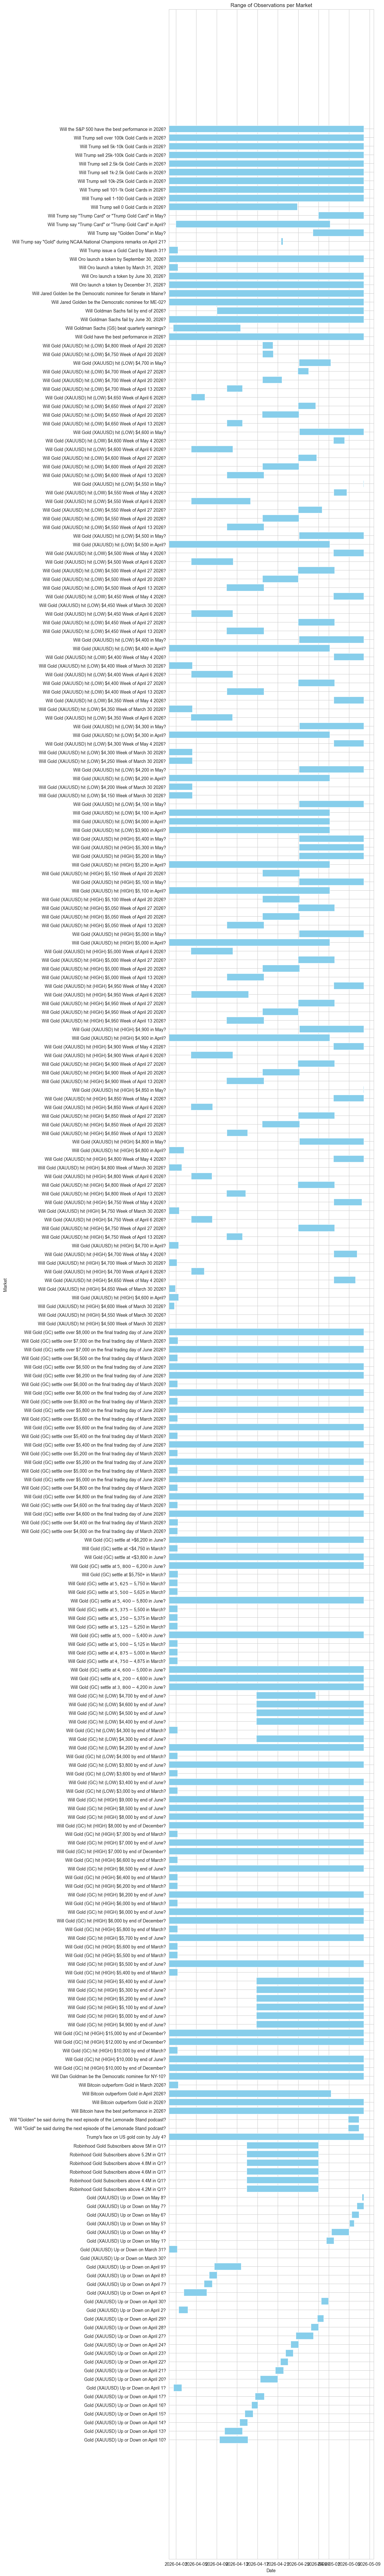

In [8]:
# Range of observations ---------------------------

# Do all markets (questions) cover the same period of time?
# Plot one horizontal bar per market from first to last non-null observation.
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(12, 0.3 * len(markets)))

for i, market in enumerate(markets):
    # Select this market from MultiIndex columns (level 1 = question/market).
    sub = df.xs(market, axis=1, level=1)
    row_has_data = sub.notna().any(axis=1)

    if not row_has_data.any():
        continue

    first_non_null = sub.index[row_has_data][0]
    last_non_null = sub.index[row_has_data][-1]
    duration_days = (last_non_null - first_non_null).total_seconds() / 86400
    plt.barh(i, duration_days, left=first_non_null, color="skyblue")

plt.yticks(range(len(markets)), markets)
plt.xlabel("Date")
plt.ylabel("Market")
plt.title("Range of Observations per Market")
plt.tight_layout()
plt.show()



## Data Wrangling

In [9]:
# Keep only near-full-span markets ---------------------------
# We need predictors to cover most of the sample window, but exact first/last
# timestamp equality is too strict on intraday scraped data.

# Refresh markets from the current df (the previous cell may have dropped some
# (variable, market) combinations, making the earlier `markets` list stale).
markets = df.columns.get_level_values(1).unique().tolist()

dataset_start = df.index.min()
dataset_end   = df.index.max()
dataset_span  = dataset_end - dataset_start

median_step = df.index.to_series().diff().dropna().median()
if pd.isna(median_step) or median_step <= pd.Timedelta(0):
    median_step = pd.Timedelta(minutes=BAR_MINUTES)
edge_tolerance = MARKET_EDGE_TOLERANCE_BARS * median_step

# A market is retained if it either covers both edges within a small tolerance
# OR spans at least MARKET_MIN_SPAN_RATIO of the total sample window.
full_length_markets = []
coverage_rows = []
for market in markets:
    sub = df.xs(market, axis=1, level=1)
    row_has_data = sub.notna().any(axis=1)
    if not row_has_data.any():
        continue
    first_obs = sub.index[row_has_data][0]
    last_obs  = sub.index[row_has_data][-1]
    market_span = last_obs - first_obs
    span_ratio = market_span / dataset_span if dataset_span > pd.Timedelta(0) else 1.0
    start_gap = first_obs - dataset_start
    end_gap = dataset_end - last_obs
    keep_market = (
        (start_gap <= edge_tolerance and end_gap <= edge_tolerance)
        or span_ratio >= MARKET_MIN_SPAN_RATIO
    )
    coverage_rows.append({
        "market": market,
        "span_ratio": float(span_ratio),
        "start_gap_min": start_gap.total_seconds() / 60,
        "end_gap_min": end_gap.total_seconds() / 60,
        "kept": keep_market,
    })
    if keep_market:
        full_length_markets.append(market)

print(f"Median polymarket step      : {median_step}")
print(f"Coverage edge tolerance     : {edge_tolerance}")
print(f"Minimum span ratio retained : {MARKET_MIN_SPAN_RATIO:.0%}")
print(f"Markets retained            : {len(full_length_markets)} / {len(markets)}")

# Drop all (variable, market) columns for markets that fail the softer coverage rule.
cols_to_drop = [col for col in df.columns if col[1] not in full_length_markets]
df_full_range = df.drop(columns=cols_to_drop)

print(f"Markets before filtering: {len(markets)}")
print(f"Markets after filtering:  {len(df_full_range.columns.get_level_values(1).unique())}")

Median polymarket step      : 0 days 00:05:03.316000
Coverage edge tolerance     : 0 days 01:00:39.792000
Minimum span ratio retained : 85%
Markets retained            : 59 / 268
Markets before filtering: 268
Markets after filtering:  59


### Numerical vs categorical features

In [10]:
# Separate predictors into numerical vs non-numerical (categorical/text/other)
import ast
import json
import re

original_predictor_frame = df_full_range.copy()
multiindex_names = df_full_range.columns.names

def parse_numeric_list(value):
    """Parse a string representing a list of numbers.
    Accepts both JSON-style ('[0.95, 0.05]') and Python-style (\"['0.95', '0.05']\") formats.
    Returns a list of floats, or None if the value cannot be parsed as a numeric list."""
    if not isinstance(value, str):
        return None
    value = value.strip()
    if not value:
        return None
    # Try JSON first (handles [0.95, 0.05])
    parsed = None
    try:
        parsed = json.loads(value)
    except (json.JSONDecodeError, ValueError):
        pass
    # Fall back to Python literal_eval (handles ['0.95', '0.05'])
    if parsed is None:
        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    if isinstance(parsed, (list, tuple)):
        result = []
        for x in parsed:
            try:
                result.append(float(x))
            except (TypeError, ValueError):
                pass
        return result if result else None
    if isinstance(parsed, (int, float)) and not isinstance(parsed, bool):
        return [float(parsed)]
    return None

def _safe_feature_name(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^0-9a-zA-Z]+", "_", text).strip("_")
    return text or "value"

def _parse_label_list(value):
    if not isinstance(value, str):
        return None
    value = value.strip()
    if not value:
        return None
    try:
        parsed = json.loads(value)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    if isinstance(parsed, list):
        return [str(x) for x in parsed]
    return None

def _expand_json_numeric_columns(sub, var_name):
    expanded_cols = {}

    # Optional label pairing for list-valued numeric fields like:
    # outcomes + outcomePrices  ->  outcomePrices__yes, outcomePrices__no, ...
    label_sub = None
    if var_name == "outcomePrices" and "outcomes" in original_predictor_frame.columns.get_level_values(0):
        try:
            label_sub = original_predictor_frame["outcomes"].reindex(columns=sub.columns)
        except Exception:
            label_sub = None

    for market in sub.columns:
        series = sub[market]
        parsed_rows = {}

        label_series = None
        if label_sub is not None:
            if isinstance(label_sub, pd.Series):
                if market == label_sub.name:
                    label_series = label_sub
            elif market in label_sub.columns:
                label_series = label_sub[market]

        for idx, raw_value in series.dropna().items():
            try:
                parsed_values = parse_numeric_list(raw_value)
            except Exception:
                continue

            if parsed_values is None:
                continue

            if isinstance(parsed_values, np.ndarray):
                parsed_values = parsed_values.tolist()
            elif isinstance(parsed_values, pd.Series):
                parsed_values = parsed_values.tolist()
            elif not isinstance(parsed_values, (list, tuple)):
                continue

            if len(parsed_values) == 0:
                continue

            labels = None
            if label_series is not None and idx in label_series.index:
                labels = _parse_label_list(label_series.loc[idx])

            for pos, numeric_value in enumerate(parsed_values):
                numeric_value = pd.to_numeric(numeric_value, errors="coerce")
                if pd.isna(numeric_value):
                    continue

                if labels is not None and pos < len(labels):
                    suffix = _safe_feature_name(labels[pos])
                else:
                    suffix = f"json_{pos}"

                derived_var = f"{var_name}__{suffix}"
                parsed_rows.setdefault(derived_var, {})[idx] = float(numeric_value)

        for derived_var, row_map in parsed_rows.items():
            expanded_cols[(derived_var, market)] = pd.Series(
                row_map, index=sub.index, dtype="float64"
            )

    if not expanded_cols:
        return None

    expanded_df = pd.DataFrame(expanded_cols, index=sub.index)
    expanded_df.columns = pd.MultiIndex.from_tuples(
        expanded_df.columns, names=multiindex_names
    )
    return expanded_df.sort_index(axis=1)

def _ensure_market_feature_multiindex(frame, frame_name):
    if isinstance(frame.columns, pd.MultiIndex):
        return frame.sort_index(axis=1)

    if len(frame.columns) == 0:
        fixed = frame.copy()
        fixed.columns = pd.MultiIndex.from_tuples([], names=multiindex_names)
        return fixed

    if all(isinstance(col, tuple) and len(col) == 2 for col in frame.columns):
        fixed = frame.copy()
        fixed.columns = pd.MultiIndex.from_tuples(list(frame.columns), names=multiindex_names)
        print(f"Normalized {frame_name} columns back to a 2-level MultiIndex.")
        return fixed.sort_index(axis=1)

    raise TypeError(
        f"{frame_name} must have 2-level (variable, market) columns; got {type(frame.columns).__name__}."
    )

# Predictor variables only (exclude target-like columns if present)
predictor_vars = sorted([
    v for v in df_full_range.columns.get_level_values(0).unique()
    if v not in {"y", "gold_close"}
])

passthrough_cols = [
    col for col in df_full_range.columns
    if col[0] in {"y", "gold_close"}
]

transformed_blocks = []
numerical_predictors = []
non_numerical_predictors = []
json_expanded_predictors = {}

for var in predictor_vars:
    sub = df_full_range[var]
    if isinstance(sub, pd.Series):
        sub = sub.to_frame()

    # First, use ordinary numeric coercion for already numeric-like columns.
    coerced = sub.apply(pd.to_numeric, errors="coerce")
    has_numeric_signal = coerced.notna().any().any()

    if has_numeric_signal:
        coerced.columns = pd.MultiIndex.from_product(
            [[var], coerced.columns], names=multiindex_names
        )
        transformed_blocks.append(coerced)
        numerical_predictors.append(var)
    else:
        # If direct coercion fails, try parsing list-like numeric strings
        # through parse_numeric_list and expand them into separate features.
        expanded_json = _expand_json_numeric_columns(sub, var)

        if expanded_json is not None and expanded_json.notna().any().any():
            transformed_blocks.append(expanded_json)
            derived_vars = sorted(expanded_json.columns.get_level_values(0).unique())
            numerical_predictors.extend(derived_vars)
            json_expanded_predictors[var] = derived_vars
        else:
            non_numerical_predictors.append(var)

predictor_frame_numeric = (
    pd.concat(transformed_blocks, axis=1).sort_index(axis=1)
    if transformed_blocks else pd.DataFrame(index=df_full_range.index)
)

passthrough_frame = (
    df_full_range.loc[:, passthrough_cols]
    if passthrough_cols else pd.DataFrame(index=df_full_range.index)
)

df_full_range_numerical = pd.concat(
    [passthrough_frame, predictor_frame_numeric], axis=1
).sort_index(axis=1)
df_full_range_numerical = _ensure_market_feature_multiindex(
    df_full_range_numerical,
    "df_full_range_numerical",
)

print(f"Numerical predictors ({len(numerical_predictors)}):")
print(numerical_predictors)

if json_expanded_predictors:
    print("\nJSON/list predictors expanded into numeric features:")
    for original_var, derived_vars in json_expanded_predictors.items():
        print(f"  - {original_var} -> {derived_vars}")

print(f"\nNon-numerical predictors ({len(non_numerical_predictors)}):")
print(non_numerical_predictors)

print(
    f"\ndf_full_range_numerical shape: {df_full_range_numerical.shape}"
)
print(
    f"Column index type: {type(df_full_range_numerical.columns).__name__}"
)

Normalized df_full_range_numerical columns back to a 2-level MultiIndex.
Numerical predictors (35):
['bestAsk', 'bestBid', 'competitive', 'customLiveness', 'groupItemThreshold', 'lastTradePrice', 'liquidity', 'liquidityClob', 'liquidityNum', 'makerBaseFee', 'oneDayPriceChange', 'oneHourPriceChange', 'oneMonthPriceChange', 'oneWeekPriceChange', 'orderMinSize', 'orderPriceMinTickSize', 'outcomePrices__no', 'outcomePrices__yes', 'rewardsMaxSpread', 'rewardsMinSize', 'spread', 'takerBaseFee', 'umaBond', 'umaReward', 'volume', 'volume1mo', 'volume1moClob', 'volume1wk', 'volume1wkClob', 'volume1yr', 'volume1yrClob', 'volume24hr', 'volume24hrClob', 'volumeClob', 'volumeNum']

JSON/list predictors expanded into numeric features:
  - outcomePrices -> ['outcomePrices__no', 'outcomePrices__yes']

Non-numerical predictors (41):
['acceptingOrders', 'acceptingOrdersTimestamp', 'active', 'approved', 'archived', 'automaticallyActive', 'clearBookOnStart', 'clobRewards', 'closed', 'createdAt', 'cyom', '

### Missingness Analysis

For each predictor variable, compute the percentage of missing (NaN) values across **all** its market columns and across **all** timestamps in `df_full_range_numerical`.  Variables with overall missingness above **20 %** are flagged as candidates for removal — they are likely too sparse to provide reliable signal.

The analysis is run on the raw panel (before any filling) so the numbers reflect true data availability.

In [11]:
# %% -- MISSINGNESS ANALYSIS --------------------------------------------------
# For each predictor variable, compute NaN rates across all market columns.
# A variable's "overall missingness" is the fraction of NaN cells in its entire
# sub-block (all timestamps × all markets).  We also report the worst (highest
# NaN rate) and best (lowest NaN rate) individual market for context.
#
# Variables above MISSINGNESS_THRESHOLD are flagged — they are prime candidates
# for removal before feature selection.

MISSINGNESS_THRESHOLD = MISSINGNESS_FILTER_THRESHOLD   # flag variables with > 20 % missing values

_pred_vars_miss = [
    v for v in df_full_range_numerical.columns.get_level_values(0).unique()
    if v != "gold_close"
]

_miss_rows = []
for _var in _pred_vars_miss:
    _sub = df_full_range_numerical[_var]
    if isinstance(_sub, pd.Series):
        _sub = _sub.to_frame()
    _sub_num = _sub.apply(pd.to_numeric, errors="coerce")

    _n_markets    = _sub_num.shape[1]
    _overall_miss = float(_sub_num.isna().values.mean())
    _per_market   = _sub_num.isna().mean()   # NaN rate per market column
    _worst_mkt    = float(_per_market.max())
    _best_mkt     = float(_per_market.min())

    _miss_rows.append({
        "variable":              _var,
        "n_markets":             _n_markets,
        "overall_miss_pct":      round(_overall_miss * 100, 2),
        "worst_market_miss_pct": round(_worst_mkt    * 100, 2),
        "best_market_miss_pct":  round(_best_mkt     * 100, 2),
        "flagged":               _overall_miss > MISSINGNESS_THRESHOLD,
    })

missingness_summary = (
    pd.DataFrame(_miss_rows)
    .sort_values("overall_miss_pct", ascending=False)
    .reset_index(drop=True)
)

# ── Display table ─────────────────────────────────────────────────────────────
_sep = "─" * 97
print(_sep)
print(f"{'Variable':<35} {'N mkts':>6}  {'Overall %':>10}  {'Worst mkt %':>12}  {'Best mkt %':>11}  {'Flag':>5}")
print(_sep)
for _, _r in missingness_summary.iterrows():
    _flag = "⚠️" if _r["flagged"] else ""
    print(
        f"{_r['variable']:<35} {int(_r['n_markets']):>6}  "
        f"{_r['overall_miss_pct']:>9.1f}%  {_r['worst_market_miss_pct']:>11.1f}%  "
        f"{_r['best_market_miss_pct']:>10.1f}%  {_flag}"
    )

_flagged_vars = missingness_summary.loc[missingness_summary["flagged"], "variable"].tolist()
print(_sep)
print(f"Variables above {MISSINGNESS_THRESHOLD * 100:.0f}% threshold : {len(_flagged_vars)} / {len(_pred_vars_miss)}")
for _v in _flagged_vars:
    print(f"  ⚠️  {_v}")

─────────────────────────────────────────────────────────────────────────────────────────────────
Variable                            N mkts   Overall %   Worst mkt %   Best mkt %   Flag
─────────────────────────────────────────────────────────────────────────────────────────────────
makerBaseFee                            59       75.6%         75.6%        75.5%  ⚠️
takerBaseFee                            59       75.6%         75.6%        75.5%  ⚠️
oneHourPriceChange                      59       63.2%         99.5%        17.1%  ⚠️
volume1wk                               59       30.1%         89.2%         0.0%  ⚠️
volume1wkClob                           59       30.1%         89.2%         0.0%  ⚠️
volume24hrClob                          59       30.1%         89.2%         0.0%  ⚠️
volume1yr                               59       30.1%         89.2%         0.0%  ⚠️
volume24hr                              59       30.1%         89.2%         0.0%  ⚠️
volume1mo                  

In [12]:
# %% -- DROP HIGH-MISSINGNESS VARIABLES (PRE-FFILL) ----------------------------
# Remove entire variable blocks (all markets) when overall missingness exceeds
# MISSINGNESS_FILTER_THRESHOLD, using the `missingness_summary` from the previous cell.

_vars_drop_high_miss = missingness_summary.loc[
    missingness_summary["overall_miss_pct"] > (MISSINGNESS_FILTER_THRESHOLD * 100),
    "variable",
].tolist()

print(
    f"Dropping variables with overall missingness > {MISSINGNESS_FILTER_THRESHOLD * 100:.0f}%: "
    f"{len(_vars_drop_high_miss)}"
)
if _vars_drop_high_miss:
    for _v in _vars_drop_high_miss:
        print(f"  - {_v}")

_cols_drop_high_miss = [
    col for col in df_full_range_numerical.columns
    if col[0] in set(_vars_drop_high_miss)
]
df_full_range_numerical = df_full_range_numerical.drop(columns=_cols_drop_high_miss)

print(f"\ndf_full_range_numerical after high-missingness drop: {df_full_range_numerical.shape}")

# Recompute missingness summary after filtering (same layout as previous table).
_pred_vars_miss_post = [
    v for v in df_full_range_numerical.columns.get_level_values(0).unique()
    if v not in {"gold_close", "y"}
]

_miss_rows_post = []
for _var in _pred_vars_miss_post:
    _sub = df_full_range_numerical[_var]
    if isinstance(_sub, pd.Series):
        _sub = _sub.to_frame()
    _sub_num = _sub.apply(pd.to_numeric, errors="coerce")

    _n_markets = _sub_num.shape[1]
    _overall_miss = float(_sub_num.isna().values.mean())
    _per_market = _sub_num.isna().mean()
    _worst_mkt = float(_per_market.max())
    _best_mkt = float(_per_market.min())

    _miss_rows_post.append({
        "variable": _var,
        "n_markets": _n_markets,
        "overall_miss_pct": round(_overall_miss * 100, 2),
        "worst_market_miss_pct": round(_worst_mkt * 100, 2),
        "best_market_miss_pct": round(_best_mkt * 100, 2),
        "flagged": _overall_miss > MISSINGNESS_THRESHOLD,
    })

missingness_summary_post = (
    pd.DataFrame(_miss_rows_post)
    .sort_values("overall_miss_pct", ascending=False)
    .reset_index(drop=True)
)

_sep = "─" * 97
print("\n" + _sep)
print(f"{'Variable':<35} {'N mkts':>6}  {'Overall %':>10}  {'Worst mkt %':>12}  {'Best mkt %':>11}  {'Flag':>5}")
print(_sep)
for _, _r in missingness_summary_post.iterrows():
    _flag = "⚠️" if _r["flagged"] else ""
    print(
        f"{_r['variable']:<35} {int(_r['n_markets']):>6}  "
        f"{_r['overall_miss_pct']:>9.1f}%  {_r['worst_market_miss_pct']:>11.1f}%  "
        f"{_r['best_market_miss_pct']:>10.1f}%  {_flag}"
    )

_flagged_vars_post = missingness_summary_post.loc[
    missingness_summary_post["flagged"], "variable"
].tolist()
print(_sep)
print(
    f"Variables above {MISSINGNESS_THRESHOLD * 100:.0f}% threshold after filtering: "
    f"{len(_flagged_vars_post)} / {len(_pred_vars_miss_post)}"
)
for _v in _flagged_vars_post:
    print(f"  ⚠️  {_v}")

Dropping variables with overall missingness > 15%: 12
  - makerBaseFee
  - takerBaseFee
  - oneHourPriceChange
  - volume1wk
  - volume1wkClob
  - volume24hrClob
  - volume1yr
  - volume24hr
  - volume1mo
  - volume1moClob
  - volume1yrClob
  - oneDayPriceChange

df_full_range_numerical after high-missingness drop: (10702, 1357)

─────────────────────────────────────────────────────────────────────────────────────────────────
Variable                            N mkts   Overall %   Worst mkt %   Best mkt %   Flag
─────────────────────────────────────────────────────────────────────────────────────────────────
oneWeekPriceChange                      59        4.6%         60.9%         0.1%  
oneMonthPriceChange                     59        4.1%         52.4%         0.0%  
bestBid                                 59        1.6%         92.1%         0.0%  
volumeClob                              59        0.2%          8.5%         0.0%  
volumeNum                               59     

In [13]:
# %% -- CENTRALIZED MISSINGNESS TREATMENT ------------------------------------
# Forward-fill df_full_range_numerical in-place so that all downstream steps
# (variance filter, SFS, RFE, export) receive pre-filled data and do not need
# to handle NaN themselves.
#
# Semantic justification: a stale Polymarket quote is still the last known
# probability — forward-filling is correct, not an approximation.
#
# NOTE: This fill is intentionally applied AFTER the analysis above so the
# missingness percentages above reflect the raw data, not the filled panel.

df_full_range_numerical = df_full_range_numerical.ffill()

_n_nan_after = int(df_full_range_numerical.isna().sum().sum())
print(f"df_full_range_numerical after forward-fill: {df_full_range_numerical.shape}")
print(f"Remaining NaN cells (leading-edge / never-observed): {_n_nan_after:,}")

df_full_range_numerical after forward-fill: (10702, 1357)
Remaining NaN cells (leading-edge / never-observed): 22,634


### Bloomberg loading for building Y and explore it

In [14]:
# %% ── CELL 3.0 : ENSURE OPENPYXL ───────────────────────────────────────────
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("openpyxl") is None:
    print("openpyxl not found. Installing via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
else:
    print("openpyxl is already installed.")


openpyxl is already installed.


In [15]:
# %% ── CELL 3 : LOAD BLOOMBERG SHEETS ────────────────────────────────────────
def load_bloomberg(xlsx_path: Path) -> dict[str, pd.DataFrame]:
    '''Load every Bloomberg sheet that has a `Date` column.
       Some sheets use `Close`, some use `Last Price` — we normalise both to `close`.'''
    xl = pd.ExcelFile(xlsx_path)
    out = {}
    for sheet in xl.sheet_names:
        df = pd.read_excel(xlsx_path, sheet_name=sheet, header=0)
        if df.empty or "Date" not in df.columns:
            continue
        df = df.rename(columns={c: c.strip() for c in df.columns})
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).set_index("Date").sort_index()
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        # normalise the price column name
        if "Close" in df.columns:
            df = df.rename(columns={"Close": "close"})
        elif "Last Price" in df.columns:
            df = df.rename(columns={"Last Price": "close"})
        else:
            numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
            if not numeric_cols:
                continue
            df = df.rename(columns={numeric_cols[-1]: "close"})
        out[sheet] = df
    return out

bb = load_bloomberg(BLOOMBERG_XLSX)
print("Bloomberg sheets loaded:", list(bb.keys()))
gold = bb[TARGET_SHEET][["close"]].rename(columns={"close": "gold_close"})
print("Gold close range:", gold.index.min(), "→", gold.index.max(), "| rows:", len(gold))


Bloomberg sheets loaded: ['GOLD USD SPOT PER OZ', 'CRUDE OIL (WTI) FUTURES PRICE', 'CRUDE OIL (BRENT) FUTURES PRICE', 'S&P 500 Index', 'USD Index', 'VIX Index', 'USGG10YR Index', 'EURUSD', 'GC1 Comdty', 'GLD US Equity']
Gold close range: 2026-04-01 00:00:00 → 2026-05-08 22:55:00 | rows: 7459


In [16]:
# %% ── CELL 3.0A : BLOOMBERG STATIONARITY SCAN ───────────────────────────────
try:
    import statsmodels.api as sm
except ModuleNotFoundError:
    %pip install statsmodels -q
    import statsmodels.api as sm

import re
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=sm.tools.sm_exceptions.InterpolationWarning)

BB_STATIONARITY_TRAIN_FRACTION = 1.0   # 1.0 = mimic Polymarket; set below 1.0 to test only on the first training prefix.

if not (0 < BB_STATIONARITY_TRAIN_FRACTION <= 1.0):
    raise ValueError(
        "BB_STATIONARITY_TRAIN_FRACTION must lie in (0, 1]. "
        f"Got {BB_STATIONARITY_TRAIN_FRACTION!r}."
    )

bb_stationarity_results = []

for sheet, df in bb.items():
    if sheet == TARGET_SHEET or "close" not in df.columns:
        continue

    feature_name = re.sub(r"[^0-9a-zA-Z]+", "_", sheet).strip("_").lower()
    s_raw = df["close"].sort_index()
    s_raw = s_raw[~s_raw.index.duplicated(keep="last")]

    s_aligned = s_raw.reindex(gold.index)
    s_filled = s_aligned.ffill(limit=TRADITIONAL_MAX_FFILL_BARS)
    s = s_filled.dropna()

    if BB_STATIONARITY_TRAIN_FRACTION < 1.0 and not s.empty:
        _n_train_obs = max(1, int(np.floor(len(s) * BB_STATIONARITY_TRAIN_FRACTION)))
        s_test = s.iloc[:_n_train_obs]
    else:
        s_test = s

    if len(s_test) < 20 or s_test.nunique() <= 1:
        continue

    try:
        adf_c = adfuller(s_test, autolag="AIC", regression="c")
        adf_ct = adfuller(s_test, autolag="AIC", regression="ct")
        kpss_c = kpss(s_test, regression="c", nlags="auto")

        bb_stationarity_results.append({
            "sheet": sheet,
            "feature_name": feature_name,
            "n_obs": len(s_test),
            "adf_p_c": adf_c[1],
            "adf_p_ct": adf_ct[1],
            "kpss_p_c": kpss_c[1],
        })
    except Exception:
        continue

bb_stationarity_results_df = pd.DataFrame(
    bb_stationarity_results,
    columns=["sheet", "feature_name", "n_obs", "adf_p_c", "adf_p_ct", "kpss_p_c"],
)

if bb_stationarity_results_df.empty:
    print("No Bloomberg series passed the ADF/KPSS scan guards.")
else:
    print(bb_stationarity_results_df.to_string(index=False))

bb_vars_to_stationarize = set(
    bb_stationarity_results_df.loc[
        (bb_stationarity_results_df["adf_p_c"] >= 0.05)
        & (bb_stationarity_results_df["kpss_p_c"] < 0.05),
        "feature_name",
    ].tolist()
    if not bb_stationarity_results_df.empty else []
)

print(
    "Bloomberg series flagged non-stationary (ADF p≥0.05 AND KPSS p<0.05): "
    f"{len(bb_vars_to_stationarize)}/{len(bb_stationarity_results_df)}"
    if len(bb_stationarity_results_df)
    else "Bloomberg series flagged non-stationary (ADF p≥0.05 AND KPSS p<0.05): 0/0"
 )
print(f"Flagged feature names: {sorted(bb_vars_to_stationarize)}")

                          sheet                  feature_name  n_obs  adf_p_c  adf_p_ct  kpss_p_c
  CRUDE OIL (WTI) FUTURES PRICE   crude_oil_wti_futures_price   7459 0.228855  0.504858      0.01
CRUDE OIL (BRENT) FUTURES PRICE crude_oil_brent_futures_price   7435 0.325088  0.599824      0.01
                  S&P 500 Index                 s_p_500_index   7273 0.786577  0.628878      0.01
                      USD Index                     usd_index   7459 0.325965  0.444885      0.01
                      VIX Index                     vix_index   7348 0.213715  0.159512      0.01
                 USGG10YR Index                usgg10yr_index   7436 0.164359  0.181325      0.01
                         EURUSD                        eurusd   7459 0.262078  0.551168      0.01
                     GC1 Comdty                    gc1_comdty   7456 0.094904  0.192511      0.01
                  GLD US Equity                 gld_us_equity   7454 0.319957  0.490139      0.01
Bloomberg series fla

In [17]:
# %% ── CELL 3.0B : BUILD + EXPORT STATIONARY BLOOMBERG PANEL ─────────────────
import json

bb_stationary_panel = pd.DataFrame(index=gold.index)
bb_stationary_panel.index.name = "Date"

bb_transform_map = {}
bb_adf_kpss_pvalues = {}
_bb_logret_count = 0
_bb_diff_count = 0
_bb_level_count = 0

for sheet, df in bb.items():
    if sheet == TARGET_SHEET or "close" not in df.columns:
        continue

    feature_name = re.sub(r"[^0-9a-zA-Z]+", "_", sheet).strip("_").lower()
    s_raw = df["close"].sort_index()
    s_raw = s_raw[~s_raw.index.duplicated(keep="last")]

    s_aligned = s_raw.reindex(gold.index)

    is_new_tick = s_aligned.notna()
    real_tick_groups = is_new_tick.cumsum()
    stale_count = (~is_new_tick).groupby(real_tick_groups).cumsum().astype(int)
    bb_stationary_panel[f"{feature_name}_stale"] = stale_count

    s_filled = s_aligned.ffill(limit=TRADITIONAL_MAX_FFILL_BARS)
    s_non_null = s_filled.dropna()

    if feature_name in bb_vars_to_stationarize:
        strictly_positive = (s_non_null > 0).all() if not s_non_null.empty else False
        if strictly_positive:
            bb_stationary_panel[f"{feature_name}_logret"] = np.log(s_filled).diff()
            bb_transform_map[feature_name] = "logret"
            _bb_logret_count += 1
        else:
            bb_stationary_panel[f"{feature_name}_diff"] = s_filled.diff()
            bb_transform_map[feature_name] = "diff"
            _bb_diff_count += 1
    else:
        bb_stationary_panel[feature_name] = s_filled
        bb_transform_map[feature_name] = "level"
        _bb_level_count += 1

    _pvalue_row = bb_stationarity_results_df.loc[
        bb_stationarity_results_df["feature_name"] == feature_name,
        ["adf_p_c", "kpss_p_c"],
    ]
    if _pvalue_row.empty:
        bb_adf_kpss_pvalues[feature_name] = {
            "adf_p_c": None,
            "kpss_p_c": None,
        }
    else:
        bb_adf_kpss_pvalues[feature_name] = {
            "adf_p_c": float(_pvalue_row.iloc[0]["adf_p_c"]),
            "kpss_p_c": float(_pvalue_row.iloc[0]["kpss_p_c"]),
        }

bb_stationary_panel_path = Path(LOCAL_DATA_DIR) / f"bloomberg_panel_stationary_{file_date}.csv"
bb_stationarity_metadata_path = Path(LOCAL_DATA_DIR) / f"bloomberg_stationarity_metadata_{file_date}.json"

bb_stationary_panel.to_csv(bb_stationary_panel_path)

bb_stationarity_metadata = {
    "file_date": file_date,
    "target_sheet": TARGET_SHEET,
    "train_fraction": BB_STATIONARITY_TRAIN_FRACTION,
    "max_ffill_bars": TRADITIONAL_MAX_FFILL_BARS,
    "transforms": bb_transform_map,
    "adf_kpss_pvalues": bb_adf_kpss_pvalues,
}
bb_stationarity_metadata_path.write_text(
    json.dumps(bb_stationarity_metadata, indent=2),
    encoding="utf-8",
)

print(f"\n{'=' * 60}")
print("BLOOMBERG STATIONARY EXPORT")
print(f"  Panel path   : {bb_stationary_panel_path}")
print(f"  Panel shape  : {bb_stationary_panel.shape}")
print(f"  Panel size   : {bb_stationary_panel_path.stat().st_size / 1024:.1f} KB")
print(f"  Metadata path: {bb_stationarity_metadata_path}")
print(
    f"  Transform summary: {_bb_logret_count + _bb_diff_count} differenced "
    f"({_bb_logret_count} logret, {_bb_diff_count} diff), {_bb_level_count} kept in levels"
 )
print(f"{'=' * 60}")


BLOOMBERG STATIONARY EXPORT
  Panel path   : Data\bloomberg_panel_stationary_2026-05-07.csv
  Panel shape  : (7459, 18)
  Panel size   : 1307.6 KB
  Metadata path: Data\bloomberg_stationarity_metadata_2026-05-07.json
  Transform summary: 9 differenced (9 logret, 0 diff), 0 kept in levels


### Bloomberg stationarity note
`BB_STATIONARITY_TRAIN_FRACTION = 1.0` mirrors the Polymarket workflow by making the ADF/KPSS decision on the full available sample. That is a mild meta look-ahead in the stationarity decision only. Set the fraction below `1.0` (for example `0.7`) to base the decision on an initial training prefix instead.

### Build the target `y`
Mimiced script from Modellin Baseline

In [18]:
# %% ── CELL 3.1 : BUILD y (log-returns over RETURN_HORIZON_MIN, lagged -HORIZON_STEPS) ───
# ─── FIX (from Operation Fixing Terrible Performance, point 5) ───────────────
# We now use a CONFIGURABLE horizon. The per-bar log-return is still computed
# at the native 5-min cadence (it's what AR features need), but the TARGET is
# the log-return over HORIZON_STEPS bars ahead:
#     y_t = log(P_{t+H}) - log(P_t)
# where H = HORIZON_STEPS = RETURN_HORIZON_MIN / BAR_MINUTES.
#
# Switching RETURN_HORIZON_MIN in the config cell is the only change needed
# to move from 1h -> 4h -> next-day returns.
# Bloomberg sheets list rows newest-first; sort_index() already fixed that.
gold["logret_bar"]     = np.log(gold["gold_close"]).diff()                    # per-bar (5-min) log-return
gold["logret_horizon"] = (np.log(gold["gold_close"])
                          - np.log(gold["gold_close"]).shift(HORIZON_STEPS))  # return realised over [t-H, t]
gold["y"]              = gold["logret_horizon"].shift(-HORIZON_STEPS)         # shift forward = realised over [t, t+H]
# Backwards-compat alias (some downstream cells still reference `logret_5m`).
gold["logret_5m"]      = gold["logret_bar"]
# (gold.index = t. gold["y"].loc[t] = log(P_{t+H}) - log(P_t), i.e. the H-bar-ahead return.)
print(f"Target horizon: {RETURN_HORIZON_MIN} min  ({HORIZON_STEPS} bars of {BAR_MINUTES} min each)")
print(gold[["gold_close","logret_bar","logret_horizon","y"]].tail(6))


Target horizon: 60 min  (12 bars of 5 min each)
                     gold_close  logret_bar  logret_horizon   y
Date                                                           
2026-05-08 22:30:00     4717.14   -0.000049       -0.001286 NaN
2026-05-08 22:35:00     4717.88    0.000157       -0.001207 NaN
2026-05-08 22:40:00     4716.74   -0.000242       -0.001834 NaN
2026-05-08 22:45:00     4715.54   -0.000254       -0.001883 NaN
2026-05-08 22:50:00     4715.14   -0.000085       -0.002036 NaN
2026-05-08 22:55:00     4715.25    0.000023       -0.001911 NaN


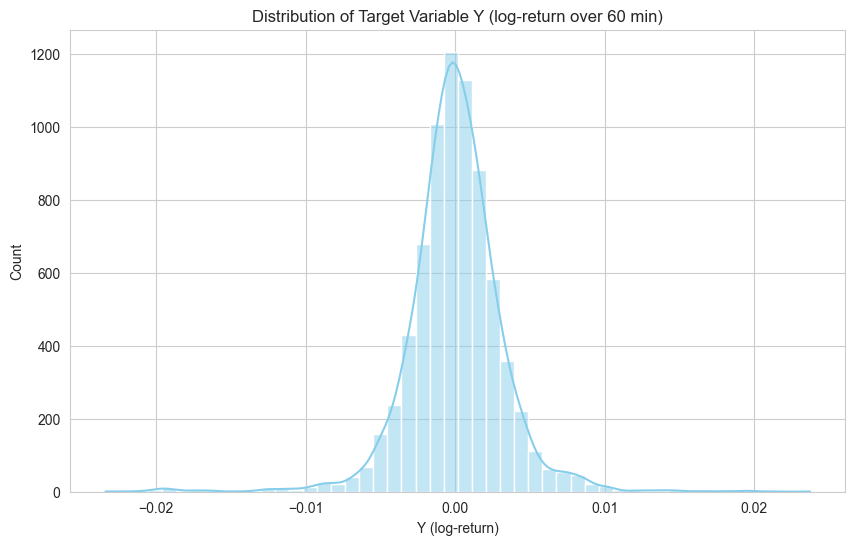

In [19]:
# Response variable distribution ---------------------------
# Using sns lineplot, let's draw the distribution of the target variable Y
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(gold["y"].dropna(), bins=50, kde=True, color="skyblue")
plt.title(f"Distribution of Target Variable Y (log-return over {RETURN_HORIZON_MIN} min)")
plt.xlabel("Y (log-return)")
plt.show()

#very nicely normally distributed with very slightly negative skew

## Feature selection (polymarket variables) - part 1


Skipped zero-range variables after coercion: ['customLiveness', 'orderMinSize', 'umaBond']


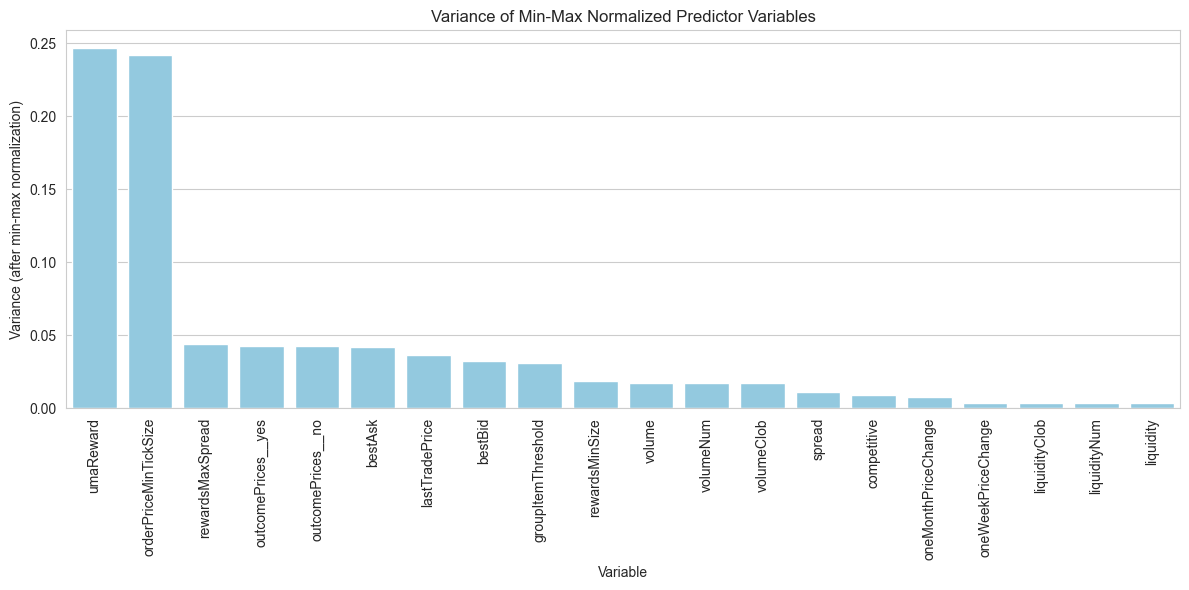

In [20]:
# Variance exploration of predictors -------------------------
# Normalize each predictor block first (min-max) so variables share a common 0..1 scale.
# Non-numeric entries are coerced to NaN; blocks with too little finite data are skipped.

predictor_vars = [col for col in df_full_range_numerical.columns.get_level_values(0).unique() if col != "gold_close"]
variances = []
skipped_non_numeric = []
skipped_zero_range = []

for var in predictor_vars:
    sub = df_full_range_numerical[var]
    numeric_sub = sub.apply(pd.to_numeric, errors="coerce")

    arr_raw = numeric_sub.to_numpy(dtype="float64")

    # Need at least 2 finite values for sample variance (ddof=1).
    if np.isfinite(arr_raw).sum() < 2:
        skipped_non_numeric.append(var)
        continue

    min_val = np.nanmin(arr_raw)
    max_val = np.nanmax(arr_raw)
    value_range = max_val - min_val
    if not np.isfinite(value_range) or value_range == 0:
        skipped_zero_range.append(var)
        continue

    arr_norm = (arr_raw - min_val) / value_range
    var_value = np.nanvar(arr_norm, ddof=1)
    if np.isnan(var_value):
        skipped_non_numeric.append(var)
        continue

    variances.append({"variable": var, "variance": var_value})

if skipped_non_numeric:
    print("Skipped non-numeric/all-NaN/insufficient-data variables:", skipped_non_numeric)
if skipped_zero_range:
    print("Skipped zero-range variables after coercion:", skipped_zero_range)

if not variances:
    raise ValueError(
        "No predictor variable had enough numeric variation after normalization."
    )

var_df = pd.DataFrame(variances).sort_values("variance", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=var_df, x="variable", y="variance", color="skyblue")
plt.xticks(rotation=90)
plt.title("Variance of Min-Max Normalized Predictor Variables")
plt.xlabel("Variable")
plt.ylabel("Variance (after min-max normalization)")
plt.tight_layout()
plt.show()

### Removing zero-variance variables


In [21]:
print(variances)
print(var_df)

[{'variable': 'bestAsk', 'variance': np.float64(0.041998105216089474)}, {'variable': 'bestBid', 'variance': np.float64(0.03258965617292166)}, {'variable': 'competitive', 'variance': np.float64(0.009385984219772313)}, {'variable': 'groupItemThreshold', 'variance': np.float64(0.030985431847970715)}, {'variable': 'lastTradePrice', 'variance': np.float64(0.03647506622797337)}, {'variable': 'liquidity', 'variance': np.float64(0.0037907714605562703)}, {'variable': 'liquidityClob', 'variance': np.float64(0.0037907714605562703)}, {'variable': 'liquidityNum', 'variance': np.float64(0.0037907714605562703)}, {'variable': 'oneMonthPriceChange', 'variance': np.float64(0.008025627296257247)}, {'variable': 'oneWeekPriceChange', 'variance': np.float64(0.003912868986166586)}, {'variable': 'orderPriceMinTickSize', 'variance': np.float64(0.24208507742370558)}, {'variable': 'outcomePrices__no', 'variance': np.float64(0.04231689991734974)}, {'variable': 'outcomePrices__yes', 'variance': np.float64(0.042317

In [22]:
# Remove near zero variance predictors ----------------
# We can assume that there is little to no predictive signal in variables with lower then 0.001 variance (after standardization)
# so let's proceed by removing ALL (variable, market) column combinations where the variable
# has cross-market variance below the threshold.
low_variance_threshold = 0.001
# var_df contains cross-market variance per variable (computed in previous cell).
low_variance_vars = set(var_df[var_df["variance"] < low_variance_threshold]["variable"].tolist())
print(f"Removing {len(low_variance_vars)} low-variance variables (variance < {low_variance_threshold}):")
print(sorted(low_variance_vars))

# df_full_range_numerical has MultiIndex columns (variable, market); drop every column whose level-0 is low-variance.
cols_to_drop = [col for col in df_full_range_numerical.columns if col[0] in low_variance_vars]
print(f"\nColumns to drop: {len(cols_to_drop)}  (= {len(low_variance_vars)} vars x markets)")
print(f"Shape before removal: {df_full_range_numerical.shape}")
df_full_range_non0var = df_full_range_numerical.drop(columns=cols_to_drop)
print(f"Shape after removal:  {df_full_range_non0var.shape}")

Removing 0 low-variance variables (variance < 0.001):
[]

Columns to drop: 0  (= 0 vars x markets)
Shape before removal: (10702, 1357)
Shape after removal:  (10702, 1357)


### Predictor EDA - should we stationarize?
We decided to transform our target variable Y into log(returns) instead of raw price to ensure stationarity.
Should we do the same for the predictors?
Let's proceed by doing the ADF and KPSS test, to test for unit root predictors.

In [23]:
try:
    import statsmodels.api as sm
except ModuleNotFoundError:
    %pip install statsmodels -q
    import statsmodels.api as sm

#silence InterpolationWarning warnings from statsmodels when running stationarity tests on short series (we expect some short series due to the market coverage filtering, and we will handle them by skipping any series with less than 20 observations or with zero variance, but statsmodels still raises warnings for these cases and clutters the output)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=sm.tools.sm_exceptions.InterpolationWarning)

import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

results = []

for col in df_full_range_non0var.columns:
    s = pd.to_numeric(df_full_range_non0var[col], errors="coerce").dropna()

    if len(s) < 20 or s.nunique() <= 1:
        continue

    try:
        adf_c = adfuller(s, autolag="AIC", regression="c")
        adf_ct = adfuller(s, autolag="AIC", regression="ct")
        kpss_c = kpss(s, regression="c", nlags="auto")

        results.append({
            "variable": col[0],
            "market": col[1],
            "n_obs": len(s),
            "adf_p_c": adf_c[1],
            "adf_p_ct": adf_ct[1],
            "kpss_p_c": kpss_c[1],
        })
    except Exception:
        continue

results_df = pd.DataFrame(results)

In [24]:
print("\nVariables that are non-stationary according to ADF and KPSS test (constant only):")
print(results_df[(results_df["adf_p_c"] >= 0.05) & (results_df["kpss_p_c"] < 0.05)][["variable", "market", "n_obs", "adf_p_c", "kpss_p_c"]].sort_values("adf_p_c"))

print("Percentage of variables that are non-stationary according to ADF and KPSS test (constant only):" \
      f" {len(results_df[(results_df['adf_p_c'] >= 0.05) & (results_df['kpss_p_c'] < 0.05)]) / len(results_df) * 100:.2f}%")


Variables that are non-stationary according to ADF and KPSS test (constant only):
          variable                                                  market  \
350  liquidityClob  Will Jared Golden be the Democratic nominee for ME-02?   
409   liquidityNum  Will Jared Golden be the Democratic nominee for ME-02?   
291      liquidity  Will Jared Golden be the Democratic nominee for ME-02?   
76         bestBid        Will Gold (GC) hit (HIGH) $8,000 by end of June?   
88         bestBid               Will Gold (GC) settle at <$3,800 in June?   
..             ...                                                     ...   
823         volume           Will Oro launch a token by December 31, 2026?   
882     volumeClob           Will Oro launch a token by December 31, 2026?   
895      volumeNum         Will Bitcoin have the best performance in 2026?   
777         volume         Will Bitcoin have the best performance in 2026?   
836     volumeClob         Will Bitcoin have the best perfo

In [25]:
# let's check if the same variable is sometimes stationary and sometimes not across different markets, which would suggest that the stationarity test results are not very reliable on this dataset (perhaps due to short series length or other issues)
# 1. Create a list to store variables that show mixed results
inconsistent_vars = []

for var in results_df["variable"].unique():
    var_results = results_df[results_df["variable"] == var]
    
    # Check if a variable is stationary in some markets but not others
    # For ADF: p < 0.05 is stationary. We check if both conditions exist in the subset.
    adf_mixed = (var_results["adf_p_c"] < 0.05).any() and (var_results["adf_p_c"] >= 0.05).any()
    
    # For KPSS: p < 0.05 is NON-stationary. We check if both conditions exist.
    kpss_mixed = (var_results["kpss_p_c"] < 0.05).any() and (var_results["kpss_p_c"] >= 0.05).any()

    if adf_mixed or kpss_mixed:
        inconsistent_vars.append({
            "variable": var,
            "tests": [t for t, mixed in zip(["ADF", "KPSS"], [adf_mixed, kpss_mixed]) if mixed]
        })

# 2. Print results clearly
print("Variables with inconsistent stationarity across markets:\n")
if not inconsistent_vars:
    print("None found. All variables behave consistently.")
else:
    for item in inconsistent_vars:
        tests_str = ", ".join(item['tests'])
        print(f"• {item['variable']}: Inconsistent in {tests_str}")

# Which variables are consistently stationary or non-stationary across all markets?
consistent_vars = []
consistently_nonstationary = []   # subset: consistent AND non-stationary in both tests

for var in results_df["variable"].unique():
    var_results = results_df[results_df["variable"] == var]
    
    adf_consistent = (var_results["adf_p_c"] < 0.05).all() or (var_results["adf_p_c"] >= 0.05).all()
    kpss_consistent = (var_results["kpss_p_c"] < 0.05).all() or (var_results["kpss_p_c"] >= 0.05).all()

    if adf_consistent or kpss_consistent:
        consistent_vars.append({
            "variable": var,
            "tests": [t for t, consistent in zip(["ADF", "KPSS"], [adf_consistent, kpss_consistent]) if consistent]
        })

    # Consistently NON-stationary: ADF fails (p >= 0.05) for ALL markets
    # AND KPSS rejects stationarity (p < 0.05) for ALL markets.
    if (var_results["adf_p_c"] >= 0.05).all() and (var_results["kpss_p_c"] < 0.05).all():
        consistently_nonstationary.append(var)

print("\nVariables with consistent stationarity across markets:\n")
if not consistent_vars:
    print("None found. All variables show some inconsistency.")
else:
    for item in consistent_vars:
        tests_str = ", ".join(item['tests'])
        print(f"• {item['variable']}: Consistent in {tests_str}")

print("\nVariables consistently non-stationary across all markets:\n")
if not consistently_nonstationary:
    print("None found.")
else:
    for var in consistently_nonstationary:
        print(f"• {var}")

Variables with inconsistent stationarity across markets:

• bestAsk: Inconsistent in ADF, KPSS
• bestBid: Inconsistent in ADF
• competitive: Inconsistent in KPSS
• lastTradePrice: Inconsistent in ADF
• liquidity: Inconsistent in ADF, KPSS
• liquidityClob: Inconsistent in ADF, KPSS
• liquidityNum: Inconsistent in ADF, KPSS
• oneMonthPriceChange: Inconsistent in ADF, KPSS
• oneWeekPriceChange: Inconsistent in ADF, KPSS
• outcomePrices__no: Inconsistent in ADF, KPSS
• outcomePrices__yes: Inconsistent in ADF, KPSS
• rewardsMinSize: Inconsistent in ADF
• spread: Inconsistent in KPSS
• volume: Inconsistent in ADF
• volumeClob: Inconsistent in ADF
• volumeNum: Inconsistent in ADF

Variables with consistent stationarity across markets:

• bestBid: Consistent in KPSS
• competitive: Consistent in ADF
• groupItemThreshold: Consistent in ADF, KPSS
• lastTradePrice: Consistent in KPSS
• orderPriceMinTickSize: Consistent in ADF, KPSS
• rewardsMaxSpread: Consistent in ADF, KPSS
• rewardsMinSize: Cons

In [26]:
# We now know that most variables show some inconsistency in stationarity across markets;
# it is important for us to stationarize non-stationary variables to make them more predictable: so,
# for variables that are inconsistently stationary across markets, we will have to treat them as non-stationary

# Treating with inconsistent variables ----------------------------------------------

# Both sets already computed in the previous cell — no re-scanning of results_df needed.
inconsistent_var_names   = {item["variable"] for item in inconsistent_vars}
vars_to_stationarize     = inconsistent_var_names | set(consistently_nonstationary)

print(f"Variables flagged as inconsistently stationary   : {sorted(inconsistent_var_names)}")
print(f"Variables flagged as consistently non-stationary : {sorted(consistently_nonstationary)}")
print(f"Total variables to stationarize                  : {len(vars_to_stationarize)}")
print(f"  {sorted(vars_to_stationarize)}")

# ── Apply stationarity transformation to flagged variable groups ──────────────
# Strategy (mirrors make_stationary_features from Modelling Baseline):
#   - strictly positive series (all non-null values > 0) → log-diff (log-return)
#   - other series (can be zero or negative)             → simple first difference
# The variable-level name is preserved so downstream SFS/RFE grouping is unaffected.

stationarized_count = 0
skipped_count = 0

for var in vars_to_stationarize:
    if var not in df_full_range_non0var.columns.get_level_values(0):
        continue
    sub = df_full_range_non0var[var]
    if isinstance(sub, pd.Series):
        sub = sub.to_frame()
    for mkt in sub.columns:
        s = pd.to_numeric(sub[mkt], errors="coerce")
        if s.dropna().empty:
            skipped_count += 1
            continue
        strictly_positive = (s.dropna() > 0).all()
        if strictly_positive:
            df_full_range_non0var[(var, mkt)] = np.log(s).diff()
        else:
            df_full_range_non0var[(var, mkt)] = s.diff()
        stationarized_count += 1

print(f"\n✅ Stationarity applied to {stationarized_count} columns "
      f"({skipped_count} skipped — all-NaN).")
print(f"   df_full_range_non0var shape unchanged: {df_full_range_non0var.shape}")

Variables flagged as inconsistently stationary   : ['bestAsk', 'bestBid', 'competitive', 'lastTradePrice', 'liquidity', 'liquidityClob', 'liquidityNum', 'oneMonthPriceChange', 'oneWeekPriceChange', 'outcomePrices__no', 'outcomePrices__yes', 'rewardsMinSize', 'spread', 'volume', 'volumeClob', 'volumeNum']
Variables flagged as consistently non-stationary : ['groupItemThreshold', 'orderPriceMinTickSize', 'rewardsMaxSpread']
Total variables to stationarize                  : 19
  ['bestAsk', 'bestBid', 'competitive', 'groupItemThreshold', 'lastTradePrice', 'liquidity', 'liquidityClob', 'liquidityNum', 'oneMonthPriceChange', 'oneWeekPriceChange', 'orderPriceMinTickSize', 'outcomePrices__no', 'outcomePrices__yes', 'rewardsMaxSpread', 'rewardsMinSize', 'spread', 'volume', 'volumeClob', 'volumeNum']

✅ Stationarity applied to 1121 columns (0 skipped — all-NaN).
   df_full_range_non0var shape unchanged: (10702, 1357)


## Feature selection (markets)


In [27]:
#which market survived the filtering?
survivors = df_full_range_non0var.columns.get_level_values(1).unique().tolist()
print("Surviving markets:")
for m in survivors:
    print(f"  - {m}")

Surviving markets:
  - Trump's face on US gold coin by July 4?
  - Will Bitcoin have the best performance in 2026?
  - Will Bitcoin outperform Gold in 2026?
  - Will Dan Goldman be the Democratic nominee for NY-10?
  - Will Gold (GC) hit (HIGH) $10,000 by end of December?
  - Will Gold (GC) hit (HIGH) $10,000 by end of June?
  - Will Gold (GC) hit (HIGH) $12,000 by end of December?
  - Will Gold (GC) hit (HIGH) $15,000 by end of December?
  - Will Gold (GC) hit (HIGH) $5,500 by end of June?
  - Will Gold (GC) hit (HIGH) $5,700 by end of June?
  - Will Gold (GC) hit (HIGH) $6,000 by end of December?
  - Will Gold (GC) hit (HIGH) $6,000 by end of June?
  - Will Gold (GC) hit (HIGH) $6,200 by end of June?
  - Will Gold (GC) hit (HIGH) $6,500 by end of June?
  - Will Gold (GC) hit (HIGH) $7,000 by end of December?
  - Will Gold (GC) hit (HIGH) $7,000 by end of June?
  - Will Gold (GC) hit (HIGH) $8,000 by end of December?
  - Will Gold (GC) hit (HIGH) $8,000 by end of June?
  - Will Gold (

### Removing non-relevant markets

In [28]:
#we have to remove all the markets that are not relevant for gold pricing:
#unfortunately we have to do that manually since the market names are not standardised in any way
non_relevant_markets = [
    "Trump's face on US gold coin by July 4?",
    "Will Dan Goldman be the Democratic nominee for NY-10?",
    "Will Goldman Sachs fail by June 30, 2026?",
    "Will Jared Golden be the Democratic nominee for ME-02?",
    "Will Jared Golden be the Democratic nominee for Senate in Maine?",
    "Will Oro launch a token by December 31, 2026?",
    "Will Oro launch a token by June 30, 2026?",
    "Will Oro launch a token by September 30, 2026?",
    "Will Trump sell 1-100 Gold Cards in 2026?",
    "Will Trump sell 101-1k Gold Cards in 2026?",
    "Will Trump sell 10k-25k Gold Cards in 2026?",
    "Will Trump sell 1k-2.5k Gold Cards in 2026?",
    "Will Trump sell 2.5k-5k Gold Cards in 2026?",
    "Will Trump sell 25k-100k Gold Cards in 2026?",
    "Will Trump sell 5k-10k Gold Cards in 2026?",
    "Will Trump sell over 100k Gold Cards in 2026?"
]

if APPLY_MANUAL_MARKET_FILTER:
    # and then we drop all the columns related to those markets:
    cols_to_drop = [col for col in df_full_range_non0var.columns if col[1] in non_relevant_markets]
    print(f"\nDropping {len(cols_to_drop)} columns related to non-relevant markets...")
    df_full_non0var_relevant = df_full_range_non0var.drop(columns=cols_to_drop)
    print(f"Shape after dropping non-relevant markets: {df_full_non0var_relevant.shape}")
else:
    print("\nManual non-relevant market removal disabled by config (APPLY_MANUAL_MARKET_FILTER=False).")
    df_full_non0var_relevant = df_full_range_non0var.copy()
    print(f"Shape without manual market drop: {df_full_non0var_relevant.shape}")


Dropping 368 columns related to non-relevant markets...
Shape after dropping non-relevant markets: (10702, 989)


### F-statistic market filter

For each retained market, fit an OLS regression of the gold log-return target on **all
Polymarket variables** for that market (after median imputation of residual NaNs).
Rank markets by the joint F-statistic (higher = more collectively predictive).

When `APPLY_FSTAT_MARKET_FILTER = True`, only the top `FSTAT_TOP_K_MARKETS` markets
survive into the PLS / Lasso CV and the filtered panel export.


In [29]:

# %% ── F-STAT MARKET FILTER ──────────────────────────────────────────────────
# For each retained market, regress all Polymarket variables for that market
# against the aligned gold target using statsmodels OLS.  Markets are ranked
# by F-statistic; the top FSTAT_TOP_K_MARKETS are retained.
# statsmodels.OLS is used (not manual SSR/SST) so .fvalue / .f_pvalue / .rsquared
# are standard and auditable.

import warnings
warnings.filterwarnings("ignore")

try:
    import statsmodels.api as sm
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
    import statsmodels.api as sm

from sklearn.impute import SimpleImputer

# ── Align target to the filtered panel's index ────────────────────────────────
# df_full_non0var_relevant has Polymarket-resolution timestamps (not Bloomberg grid).
# We align the Bloomberg target (gold["y"]) to the same index via reindex + ffill.
_y_for_fstat = (
    gold["y"]
    .reindex(df_full_non0var_relevant.index, method="ffill")
)

_markets_for_fstat = df_full_non0var_relevant.columns.get_level_values(1).unique().tolist()
print(f"Markets entering F-stat filter : {len(_markets_for_fstat)}")

fstat_rows = []

for _m in _markets_for_fstat:
    # Slice all variables for this market
    _X_m = df_full_non0var_relevant.xs(_m, axis=1, level=1)
    if isinstance(_X_m, pd.Series):
        _X_m = _X_m.to_frame()

    # Coerce to numeric (may have string booleans from earlier stages)
    _X_m = _X_m.apply(pd.to_numeric, errors="coerce")

    # Align with target; drop rows where target is NaN
    _y_m = _y_for_fstat.reindex(_X_m.index)
    _valid = _y_m.notna()
    _X_m  = _X_m.loc[_valid]
    _y_m  = _y_m.loc[_valid]

    # Drop columns that are entirely NaN for this market
    _all_nan_cols = _X_m.columns[_X_m.isna().all()]
    if len(_all_nan_cols):
        _X_m = _X_m.drop(columns=_all_nan_cols)

    if _X_m.empty or len(_X_m) < FSTAT_MIN_OBS_PER_MARKET:
        print(f"  ⏭  {_m[:60]:<60}  rows={len(_X_m)}  (below FSTAT_MIN_OBS_PER_MARKET={FSTAT_MIN_OBS_PER_MARKET})")
        continue

    n_vars = _X_m.shape[1]
    if len(_X_m) - n_vars - 1 <= 0:
        print(f"  ⏭  {_m[:60]:<60}  n-p-1 <= 0  (too few rows for {n_vars} vars)")
        continue

    # Median-impute residual NaNs (SimpleImputer fits on the available data)
    _imputer = SimpleImputer(strategy="median")
    _X_imp   = _imputer.fit_transform(_X_m)

    # OLS: gold_target ~ all polymarket variables for this market
    _X_ols = sm.add_constant(_X_imp, has_constant="add")
    _ols   = sm.OLS(_y_m.values, _X_ols).fit()

    fstat_rows.append({
        "market"  : _m,
        "n_obs"   : len(_X_m),
        "n_vars"  : n_vars,
        "r2"      : float(_ols.rsquared),
        "F"       : float(_ols.fvalue),
        "p_value" : float(_ols.f_pvalue),
    })

fstat_ranking = (
    pd.DataFrame(fstat_rows)
    .sort_values("F", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 50 markets by F-statistic:")
pd.set_option("display.max_colwidth", 80)
print(fstat_ranking.head(50).to_string(index=False))

# Save full ranking to CSV
_fstat_csv_path = Path(LOCAL_DATA_DIR) / f"fstat_market_ranking_{file_date}.csv"
fstat_ranking.to_csv(_fstat_csv_path, index=False)
print(f"\nFull F-stat ranking saved  →  {_fstat_csv_path}")

# ── Apply filter ──────────────────────────────────────────────────────────────
if APPLY_FSTAT_MARKET_FILTER:
    _top_k_markets = fstat_ranking.head(FSTAT_TOP_K_MARKETS)["market"].tolist()
    _cols_to_drop  = [
        col for col in df_full_non0var_relevant.columns
        if col[1] not in set(_top_k_markets)
    ]
    df_full_non0var_relevant = df_full_non0var_relevant.drop(columns=_cols_to_drop)
    print(f"\nApplied F-stat filter: retained top {FSTAT_TOP_K_MARKETS} markets.")
    print(f"df_full_non0var_relevant shape after filter: {df_full_non0var_relevant.shape}")
else:
    print("\nF-stat filter disabled (APPLY_FSTAT_MARKET_FILTER=False) — all markets kept.")



Markets entering F-stat filter : 43

Top 50 markets by F-statistic:
                                                                  market  n_obs  n_vars       r2        F  p_value
Will Gold (GC) settle over $5,600 on the final trading day of June 2026?  10529      23 0.001036 0.991994 0.450754
                               Will Gold (GC) settle at <$3,800 in June?  10529      23 0.000974 0.932240 0.507692
                         Will Gold (GC) hit (LOW) $4,200 by end of June?  10529      23 0.001164 0.875222 0.585996
Will Gold (GC) settle over $5,800 on the final trading day of June 2026?  10529      23 0.000813 0.777600 0.663004
                   Will Gold (GC) hit (HIGH) $15,000 by end of December?  10529      23 0.000700 0.670171 0.768169
                        Will Gold (GC) hit (HIGH) $5,700 by end of June?  10529      23 0.000954 0.669334 0.817126
                        Will Gold (GC) hit (HIGH) $6,200 by end of June?  10529      23 0.000858 0.601627 0.876148
            

## PLS Dimensionality Reduction and Lasso Feature Selection

This section replaces the previous SFS (market-level forward selection) and RFE (variable-level backward elimination) stages.

Two parallel dimensionality-reduction pipelines are applied to the Polymarket predictor block (`df_full_non0var_relevant`):

1. **PLS** (`PLSRegression`) — compresses the Polymarket block to `n_components` latent factors. Components are named `pls_comp_01`, `pls_comp_02`, … AR features are **excluded** from PLS and must be appended by Modelling Baseline.

2. **Lasso** — linear regularisation that zeros out low-signal columns. The surviving (non-zero coefficient) columns from the original feature matrix are exported for downstream modelling.

Both pipelines:
- Standardise the Polymarket predictors **inside each CV fold** (fit on train, apply to val) to prevent leakage.
- Are tuned with the same expanding walk-forward CV used in Modelling Baseline (`TimeSeriesSplit`, `CV_N_SPLITS` folds, `CV_GAP_BARS` gap).
- Use RMSE as the selection criterion.
- Apply the **one-standard-error rule** to pick the simplest model within one SE of the best RMSE.

#### EDA: Correlation matrices (Polymarket panel)

This section computes correlation matrices for:
1. All variables within a selected market (question).
2. All markets for a selected variable.

These are for EDA only and do not affect any filters, transforms, or exports.

In [2]:
# %% ── CELL EDA-1 : CORRELATION MATRICES (EDA ONLY) ───────────────────────────
from IPython.display import display
import pandas as pd

# Example EDA targets — safe defaults that the user can edit
EDA_MARKET_QUESTION = None  # e.g. "Will Trump win 2028?"
EDA_VARIABLE_NAME = None    # e.g. "yes_price"

# Use an existing Polymarket panel if present; otherwise fall back to the
# transformed MultiIndex panel built earlier in the notebook.
df_poly = globals().get("df_poly", globals().get("df_full_non0var_relevant"))

if df_poly is None:
    print(
        "Skipping EDA correlation matrices: no `df_poly` or "
        "`df_full_non0var_relevant` found in memory yet."
    )
elif not isinstance(df_poly.columns, pd.MultiIndex) or df_poly.columns.nlevels != 2:
    print(
        "Skipping EDA correlation matrices: expected 2-level MultiIndex "
        "columns structured as (variable, question)."
    )
else:
    df_poly_eda = df_poly.rename_axis(columns=["variable", "question"]).apply(
        pd.to_numeric, errors="coerce"
    )

    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        _eda_can_plot = True
    except Exception:
        _eda_can_plot = False

    corr_vars_in_market = None
    corr_markets_for_var = None

    if EDA_MARKET_QUESTION is not None:
        try:
            df_q = df_poly_eda.xs(EDA_MARKET_QUESTION, level="question", axis=1)
        except KeyError:
            print(f"EDA_MARKET_QUESTION not found: {EDA_MARKET_QUESTION!r}")
        else:
            if isinstance(df_q, pd.Series):
                df_q = df_q.to_frame()
            corr_vars_in_market = df_q.corr()
            display(corr_vars_in_market)

            if _eda_can_plot and not corr_vars_in_market.empty:
                plt.figure(figsize=(8, 6))
                sns.heatmap(corr_vars_in_market, cmap="coolwarm", center=0)
                plt.title(
                    f"Correlation: all variables within market\n{EDA_MARKET_QUESTION}"
                )
                plt.tight_layout()
                plt.show()

    if EDA_VARIABLE_NAME is not None:
        try:
            df_v = df_poly_eda.xs(EDA_VARIABLE_NAME, level="variable", axis=1)
        except KeyError:
            print(f"EDA_VARIABLE_NAME not found: {EDA_VARIABLE_NAME!r}")
        else:
            if isinstance(df_v, pd.Series):
                df_v = df_v.to_frame()
            corr_markets_for_var = df_v.corr()
            display(corr_markets_for_var)

            if _eda_can_plot and not corr_markets_for_var.empty:
                plt.figure(figsize=(8, 6))
                sns.heatmap(corr_markets_for_var, cmap="coolwarm", center=0)
                plt.title(
                    f"Correlation: all markets for variable\n{EDA_VARIABLE_NAME}"
                )
                plt.tight_layout()
                plt.show()

Skipping EDA correlation matrices: no `df_poly` or `df_full_non0var_relevant` found in memory yet.


In [30]:

# %% ── CELL DR-1 : IMPORTS + ALIGN POLYMARKET TO BLOOMBERG 5-MIN GRID ────────
import warnings
warnings.filterwarnings("ignore")
import re
from hashlib import md5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


def _slugify(text: str, maxlen: int = 55) -> str:
    text = text.lower()[:maxlen]
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def _flat_col_name(var: str, market: str) -> str:
    """Stable slug: var__slugified-market_hash6.  Mirrors the Tabular Export convention."""
    suffix = md5(market.encode("utf-8")).hexdigest()[:6]
    return f"{var}__{_slugify(market)}_{suffix}"


resample_rule = f"{BAR_MINUTES}min"

# ── Build Polymarket predictor matrix from the filtered panel ─────────────────
# df_full_non0var_relevant is the output of the non-relevant markets removal cell
# and the F-statistic market filter:
#   - MultiIndex columns (variable, market)
#   - Already stationarised, zero-variance and non-relevant markets removed
#   - Top-K markets retained by F-statistic (if APPLY_FSTAT_MARKET_FILTER=True)
#   - AR features are NOT present here — they stay in Modelling Baseline
X_poly_mi = df_full_non0var_relevant.drop(
    columns=[col for col in df_full_non0var_relevant.columns
             if col[0] in {"y", "gold_close"}]
)
X_poly_mi = X_poly_mi.apply(pd.to_numeric, errors="coerce")

all_nan_cols = X_poly_mi.columns[X_poly_mi.isna().all()]
if len(all_nan_cols):
    print(f"Dropping {len(all_nan_cols)} all-NaN columns before alignment.")
    X_poly_mi = X_poly_mi.drop(columns=all_nan_cols)

# ── Align to Bloomberg 5-min grid ─────────────────────────────────────────────
# Same logic as SFS/RFE: resample both sides to BAR_MINUTES, merge on common
# timestamps, forward-fill Polymarket values (stale quote is the truth),
# then drop rows where the target y is undefined.
window_start = max(X_poly_mi.index.min(), gold.index.min())
window_end   = min(X_poly_mi.index.max(), gold.index.max())

X_grid = (
    X_poly_mi.loc[window_start:window_end]
    .sort_index()
    .resample(resample_rule)
    .last()
    .ffill()
)
y_grid = (
    gold["y"].loc[window_start:window_end]
    .sort_index()
    .resample(resample_rule)
    .last()
)

common_idx = X_grid.index.intersection(y_grid.index)
X_aligned  = X_grid.loc[common_idx]
y_aligned  = y_grid.loc[common_idx]

# Numeric safety — replace inf before any further processing
X_aligned = X_aligned.replace([np.inf, -np.inf], np.nan)

# Drop rows where the target is undefined or all predictors are NaN
valid_mask = y_aligned.notna() & X_aligned.notna().any(axis=1)
X_aligned  = X_aligned.loc[valid_mask]
y_aligned  = y_aligned.loc[valid_mask]

# Flatten MultiIndex columns → var__slugified_market_hash  (mirrors gold_panel naming)
X_flat = X_aligned.copy()
X_flat.columns = [_flat_col_name(var, mkt) for var, mkt in X_aligned.columns]

# Forward-fill residual NaN within each column, then fill series-start NaN with 0
X_flat = X_flat.ffill().fillna(0.0)
X_flat.index.name = "scraped_at"

# Materialise as numpy arrays — reused by both PLS and Lasso CV loops
X_np = X_flat.to_numpy(dtype=np.float64)
y_np = y_aligned.to_numpy(dtype=np.float64)

print(f"Aligned X shape   : {X_flat.shape}")
print(f"Aligned y shape   : {y_aligned.shape}")
print(f"y stats           : mean={y_np.mean():.4e}  std={y_np.std():.4e}  "
      f"min={y_np.min():.4e}  max={y_np.max():.4e}")
print(f"Sample col names  : {list(X_flat.columns[:3])}")

# ── PRIMARY EXPORT: filtered raw panel for Modelling Baseline ─────────────────
# This is the main output of this notebook.  Modelling Baseline reads this file
# and re-fits PLS/Lasso inside each walk-forward window — no full-sample leakage.
# The panel includes all filters (span, missingness, zero-variance, manual exclusion,
# F-statistic).  AR features are NOT included — Modelling Baseline builds them.
_filt_panel_name = f"polymarket_panel_filtered_{file_date}.csv"
_filt_panel_path = Path(LOCAL_DATA_DIR) / _filt_panel_name
X_flat.to_csv(_filt_panel_path)
print(f"\n{'='*60}")
print(f"PRIMARY EXPORT: filtered raw panel")
print(f"  Path  : {_filt_panel_path}")
print(f"  Shape : {X_flat.shape}")
print(f"  Size  : {_filt_panel_path.stat().st_size / 1024:.1f} KB")
print(f"  → Load in Modelling Baseline with FE_INPUT_MODE='raw_panel'")
print(f"{'='*60}")



Aligned X shape   : (7171, 690)
Aligned y shape   : (7171,)
y stats           : mean=9.8984e-06  std=3.2363e-03  min=-2.3389e-02  max=2.3726e-02
Sample col names  : ['bestAsk__will_gold_gc_hit_high_10_000_by_end_of_december_85e73e', 'bestAsk__will_gold_gc_hit_high_10_000_by_end_of_june_80bda7', 'bestAsk__will_gold_gc_hit_high_12_000_by_end_of_december_c3eadc']

PRIMARY EXPORT: filtered raw panel
  Path  : Data\polymarket_panel_filtered_2026-05-07.csv
  Shape : (7171, 690)
  Size  : 31694.5 KB
  → Load in Modelling Baseline with FE_INPUT_MODE='raw_panel'


### PLS: Tuning n_components

`PLSRegression` is fit on the **Polymarket predictor block only** (AR features excluded).

Tuning procedure for each `n_components` candidate in `PLS_N_COMPONENTS_GRID` (1 to 20):
1. Split the aligned time series into `CV_N_SPLITS` expanding folds with a `CV_GAP_BARS`-bar gap (same structure as Modelling Baseline's walk-forward CV).
2. In each fold:
   - Fit `StandardScaler` on the training split only → transform both splits.
   - Fit `PLSRegression(n_components)` on the scaled training split.
   - Predict on the validation split → compute RMSE.
3. Report mean ± std RMSE across folds.

**Component selection** — one-standard-error rule: choose the smallest `n_components` whose mean CV RMSE falls within one standard error of the global minimum RMSE. This favours parsimony when several component counts perform similarly.

In [31]:

# %% ── CELL PLS-1 : PLS WALK-FORWARD CV TUNING ───────────────────────────────
# Walk-forward CV aligned with Modelling Baseline:
#   - TimeSeriesSplit with CV_N_SPLITS folds, expanding window (CV_MAX_TRAIN_SIZE=None)
#   - Gap = max(HORIZON_STEPS, CV_GAP_BARS) so the val split starts at least
#     HORIZON_STEPS bars after the train split ends (no target leakage).
# For each n_components candidate:
#   - In every fold: fit StandardScaler + PLSRegression on TRAIN only,
#     transform/predict on VAL only → compute fold RMSE.
#   - Record mean ± std RMSE across folds.

tscv_pls = TimeSeriesSplit(
    n_splits      = CV_N_SPLITS,
    gap           = max(HORIZON_STEPS, CV_GAP_BARS),
    max_train_size= CV_MAX_TRAIN_SIZE,
)

pls_results = []

for n in PLS_N_COMPONENTS_GRID:
    # Cap n_components at the number of available features (edge case)
    n_safe = min(n, X_np.shape[1])
    fold_rmse = []

    for train_idx, val_idx in tscv_pls.split(X_np):
        # Skip degenerate folds
        if len(train_idx) < n_safe + 1 or len(val_idx) < 1:
            continue

        # ── Fit scaler and PLS on training fold only (no leakage) ──────────
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_np[train_idx])
        X_va   = scaler.transform(X_np[val_idx])

        # scale=False: the external StandardScaler above is the only scaler;
        # PLSRegression's own internal scaling is disabled to avoid double-scaling.
        pls    = PLSRegression(n_components=n_safe, max_iter=500, scale=False)
        pls.fit(X_tr, y_np[train_idx])

        y_pred = pls.predict(X_va).ravel()
        rmse   = float(np.sqrt(mean_squared_error(y_np[val_idx], y_pred)))
        fold_rmse.append(rmse)

    if not fold_rmse:
        print(f"  n_components={n:>2d}  |  skipped (no valid folds)")
        continue

    mean_rmse = float(np.mean(fold_rmse))
    std_rmse  = float(np.std(fold_rmse, ddof=1)) if len(fold_rmse) > 1 else 0.0

    pls_results.append({
        "n_components": n,
        "mean_rmse"   : mean_rmse,
        "std_rmse"    : std_rmse,
        "n_folds"     : len(fold_rmse),
    })
    print(f"  n_components={n:>2d}  |  mean RMSE={mean_rmse:.6e}"
          f"  ±{std_rmse:.2e}  ({len(fold_rmse)} folds)")

pls_cv_df = pd.DataFrame(pls_results)
print("\nPLS CV results table:")
print(pls_cv_df.to_string(index=False))



  n_components= 1  |  mean RMSE=1.854567e-02  ±3.45e-02  (5 folds)
  n_components= 2  |  mean RMSE=1.814006e-02  ±3.35e-02  (5 folds)
  n_components= 3  |  mean RMSE=1.182875e-02  ±1.89e-02  (5 folds)
  n_components= 4  |  mean RMSE=1.548232e-02  ±2.69e-02  (5 folds)
  n_components= 5  |  mean RMSE=1.884896e-02  ±3.41e-02  (5 folds)
  n_components= 6  |  mean RMSE=1.920428e-02  ±3.48e-02  (5 folds)
  n_components= 7  |  mean RMSE=2.055396e-02  ±3.77e-02  (5 folds)
  n_components= 8  |  mean RMSE=2.372883e-02  ±4.46e-02  (5 folds)
  n_components= 9  |  mean RMSE=2.693509e-02  ±5.16e-02  (5 folds)
  n_components=10  |  mean RMSE=2.959228e-02  ±5.74e-02  (5 folds)
  n_components=11  |  mean RMSE=3.375243e-02  ±6.66e-02  (5 folds)
  n_components=12  |  mean RMSE=3.801652e-02  ±7.61e-02  (5 folds)
  n_components=13  |  mean RMSE=4.225321e-02  ±8.55e-02  (5 folds)
  n_components=14  |  mean RMSE=4.562274e-02  ±9.29e-02  (5 folds)
  n_components=15  |  mean RMSE=4.870976e-02  ±9.97e-02  (5 fo

Best mean RMSE           : 1.182875e-02  at n_components=3
Selected n_components    : 3  (lowest mean CV RMSE)


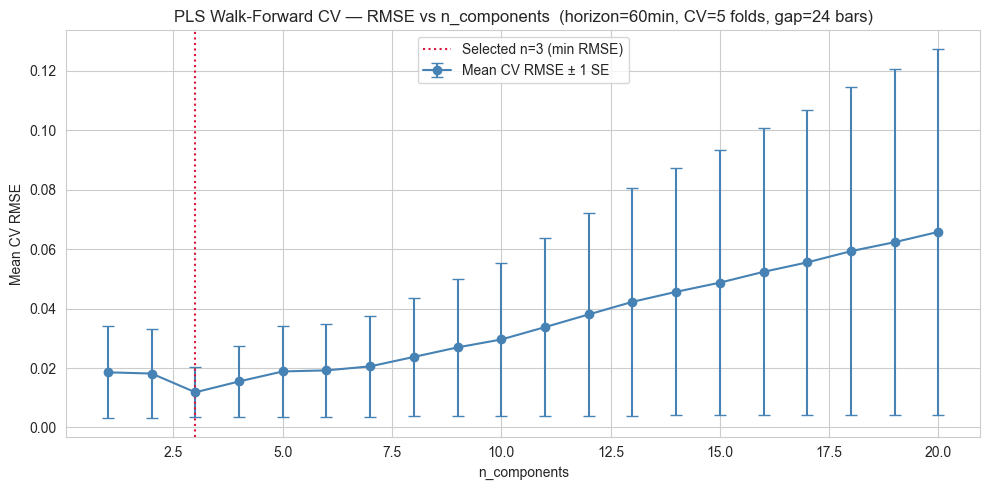

In [32]:
# %% ── CELL PLS-2 : SELECT n_components (lowest mean CV RMSE) + LINE PLOT ────
# Selection rule:
#   Pick the n_components with the LOWEST mean CV RMSE across folds.

if pls_cv_df.empty:
    raise RuntimeError("PLS CV produced no results — check CV fold sizes.")

best_idx   = int(pls_cv_df["mean_rmse"].idxmin())
best_rmse  = pls_cv_df.loc[best_idx, "mean_rmse"]
selected_n_pls = int(pls_cv_df.loc[best_idx, "n_components"])

print(f"Best mean RMSE           : {best_rmse:.6e}  "
      f"at n_components={pls_cv_df.loc[best_idx, 'n_components']}")
print(f"Selected n_components    : {selected_n_pls}  (lowest mean CV RMSE)")

# ── Line plot: RMSE ± 1 SE vs n_components ────────────────────────────────────
se_bars = pls_cv_df["std_rmse"] / np.sqrt(pls_cv_df["n_folds"])

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    pls_cv_df["n_components"],
    pls_cv_df["mean_rmse"],
    yerr=se_bars,
    fmt="o-",
    capsize=4,
    label="Mean CV RMSE ± 1 SE",
    color="steelblue",
)
ax.axvline(selected_n_pls,
           color="crimson", linestyle=":",
           label=f"Selected n={selected_n_pls} (min RMSE)")
ax.set_xlabel("n_components")
ax.set_ylabel("Mean CV RMSE")
ax.set_title(f"PLS Walk-Forward CV — RMSE vs n_components  "
             f"(horizon={RETURN_HORIZON_MIN}min, CV={CV_N_SPLITS} folds, gap={CV_GAP_BARS} bars)")
ax.legend()
plt.tight_layout()
plt.show()


In [33]:
# %% ── CELL PLS-2.1 : PERSIST SELECTED PLS n_components ───────────────────────
from datetime import datetime, timezone
import json
from pathlib import Path

pls_selection_dir = Path("Feature selection log")
pls_selection_dir.mkdir(parents=True, exist_ok=True)

pls_selection_date = datetime.now(timezone.utc).date().isoformat()
pls_selection_path = pls_selection_dir / f"pls_n_components_{pls_selection_date}.json"
pls_selection_latest_path = pls_selection_dir / "pls_n_components_latest.json"

rmse_by_n_components = {
    str(int(row["n_components"])): float(row["mean_rmse"])
    for _, row in pls_cv_df.iterrows()
}
rmse_se_by_n_components = {
    str(int(row["n_components"])): float(row["std_rmse"] / np.sqrt(row["n_folds"]))
    for _, row in pls_cv_df.iterrows()
}

pls_selection_payload = {
    "n_components": int(selected_n_pls),
    "selection_method": "TimeSeriesSplit CV + minimum mean RMSE",
    "cv_n_splits": int(CV_N_SPLITS),
    "cv_gap_bars": int(CV_GAP_BARS),
    "grid_searched": [int(n) for n in PLS_N_COMPONENTS_GRID],
    "rmse_by_n_components": rmse_by_n_components,
    "rmse_se_by_n_components": rmse_se_by_n_components,
    "best_by_rmse": int(pls_cv_df.loc[best_idx, "n_components"]),
    "selected_by_min_rmse": int(selected_n_pls),
    "selected_after_1se": int(selected_n_pls),
    "n_train_samples": int(X_np.shape[0]),
    "n_poly_features": int(X_np.shape[1]),
    "fe_notebook_version": Path("PLS - Feature Engineering SQL polymarket database.ipynb").name,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds").replace("+00:00", "Z"),
}

payload_json = json.dumps(pls_selection_payload, indent=2)
pls_selection_path.write_text(payload_json, encoding="utf-8")
pls_selection_latest_path.write_text(payload_json, encoding="utf-8")

print(f"Selected n_components    : {selected_n_pls}")
print(f"Grid searched            : {pls_selection_payload['grid_searched']}")
print("Mean CV RMSE by n        :")
for n in pls_selection_payload["grid_searched"]:
    key = str(n)
    if key in rmse_by_n_components:
        print(
            f"  n={n:>2d}  rmse={rmse_by_n_components[key]:.6e}  "
            f"se={rmse_se_by_n_components[key]:.2e}"
        )
    else:
        print(f"  n={n:>2d}  rmse=SKIPPED")
print(f"Dated JSON path          : {pls_selection_path}")
print(f"Latest JSON path         : {pls_selection_latest_path}")

Selected n_components    : 3
Grid searched            : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Mean CV RMSE by n        :
  n= 1  rmse=1.854567e-02  se=1.54e-02
  n= 2  rmse=1.814006e-02  se=1.50e-02
  n= 3  rmse=1.182875e-02  se=8.44e-03
  n= 4  rmse=1.548232e-02  se=1.20e-02
  n= 5  rmse=1.884896e-02  se=1.53e-02
  n= 6  rmse=1.920428e-02  se=1.56e-02
  n= 7  rmse=2.055396e-02  se=1.69e-02
  n= 8  rmse=2.372883e-02  se=2.00e-02
  n= 9  rmse=2.693509e-02  se=2.31e-02
  n=10  rmse=2.959228e-02  se=2.57e-02
  n=11  rmse=3.375243e-02  se=2.98e-02
  n=12  rmse=3.801652e-02  se=3.40e-02
  n=13  rmse=4.225321e-02  se=3.82e-02
  n=14  rmse=4.562274e-02  se=4.15e-02
  n=15  rmse=4.870976e-02  se=4.46e-02
  n=16  rmse=5.234509e-02  se=4.82e-02
  n=17  rmse=5.552404e-02  se=5.14e-02
  n=18  rmse=5.929891e-02  se=5.51e-02
  n=19  rmse=6.232105e-02  se=5.81e-02
  n=20  rmse=6.578189e-02  se=6.15e-02
Dated JSON path          : Feature selection log\pls_n_components

### PLS — Full-sample fit and export

**⚠️ Descriptive artefact only — fit on the full sample. Do NOT use as direct input to backtests.
Modelling Baseline re-fits PLS/Lasso inside each walk-forward training window using the filtered raw panel below.**

The exported PLS component CSV is saved for research inspection (e.g. to visualise how the
latent factors align with macro events) and not as a modelling input.


In [34]:

# %% ── CELL PLS-3 : FIT FINAL PLS ON FULL DATA + DESCRIPTIVE EXPORT ──────────
# Fits on the FULL aligned dataset — for research inspection only.
# Modelling Baseline re-fits PLS inside each walk-forward window.

n_safe_final = min(selected_n_pls, X_np.shape[1])

scaler_pls_final = StandardScaler()
X_scaled_final   = scaler_pls_final.fit_transform(X_np)

# scale=False: the external StandardScaler above is the only scaler;
# PLSRegression's own internal scaling is disabled to avoid double-scaling.
pls_final = PLSRegression(n_components=n_safe_final, max_iter=500, scale=False)
pls_final.fit(X_scaled_final, y_np)

# x_scores_ contains the latent factors (shape: n_rows × n_components)
X_pls_scores  = pls_final.x_scores_
pls_col_names = [f"pls_comp_{i+1:02d}" for i in range(n_safe_final)]

df_pls            = pd.DataFrame(X_pls_scores, index=X_flat.index, columns=pls_col_names)
df_pls.index.name = "scraped_at"

print(f"PLS component matrix shape : {df_pls.shape}")
print(f"Selected n_components      : {n_safe_final}")
print(f"Component columns          : {pls_col_names}")
print(f"\nFirst 3 rows:")
print(df_pls.head(3).to_string())

# ── Variance explained per component (informational) ─────────────────────────
x_var_total = np.var(X_scaled_final, axis=0).sum()
x_var_comp  = np.var(X_pls_scores, axis=0)
var_pct     = 100 * x_var_comp / x_var_total
print(f"\nVariance of X explained per PLS component (%):")
for i, (pct, name) in enumerate(zip(var_pct, pls_col_names)):
    print(f"  {name}: {pct:.2f}%")
print(f"  Total captured: {var_pct.sum():.2f}%")

# ── Export to CSV (descriptive artefact — NOT for backtesting) ────────────────
pls_csv_name = f"df_pls_descriptive_{file_date}.csv"
pls_csv_path = Path(LOCAL_DATA_DIR) / pls_csv_name
df_pls.to_csv(pls_csv_path)
print(f"\nPLS descriptive dataset saved  →  {pls_csv_path}")
print(f"  ⚠️  DESCRIPTIVE ONLY — fit on full sample. Do NOT use as direct modelling input.")
print(f"File size                      :  {pls_csv_path.stat().st_size / 1024:.1f} KB")



PLS component matrix shape : (7171, 3)
Selected n_components      : 3
Component columns          : ['pls_comp_01', 'pls_comp_02', 'pls_comp_03']

First 3 rows:
                     pls_comp_01  pls_comp_02  pls_comp_03
scraped_at                                                
2026-04-01 00:00:00    -0.363012     0.273960    -0.062449
2026-04-01 00:05:00     0.767816    -0.142528     0.415159
2026-04-01 00:10:00    -0.591257     0.449270    -0.423527

Variance of X explained per PLS component (%):
  pls_comp_01: 5.25%
  pls_comp_02: 1.97%
  pls_comp_03: 4.54%
  Total captured: 11.77%

PLS descriptive dataset saved  →  Data\df_pls_descriptive_2026-05-07.csv
  ⚠️  DESCRIPTIVE ONLY — fit on full sample. Do NOT use as direct modelling input.
File size                      :  568.3 KB


### Lasso: Tuning alpha

`Lasso` selects features by shrinking uninformative coefficients to exactly zero.

Tuning procedure for each `alpha` candidate in `LASSO_ALPHA_GRID`:
1. Same expanding walk-forward CV as PLS (`CV_N_SPLITS` folds, `CV_GAP_BARS` gap).
2. In each fold: fit `StandardScaler` + `Lasso(alpha)` on the training split only, predict on the validation split → compute fold RMSE.
3. Report mean ± std RMSE across folds.

**Alpha selection** — one-standard-error rule: choose the **largest** alpha (most regularised, fewest retained features) whose mean CV RMSE falls within one standard error of the minimum. This maximises feature sparsity without sacrificing predictive accuracy beyond one SE.

**Output**: the original (pre-standardised) feature values for columns with non-zero coefficients under the selected alpha are exported to CSV.

In [35]:

# %% ── CELL LASSO-1 : LASSO WALK-FORWARD CV TUNING (LassoCV) ─────────────────
# Uses sklearn LassoCV inside a Pipeline instead of a manual alpha grid loop.
# LassoCV fits the full regularisation path in one pass and selects the best
# alpha by CV.  The one-standard-error rule is then applied manually from
# mse_path_ (sklearn does not expose this natively).
#
# TimeSeriesSplit mirrors the CV structure from Modelling Baseline:
#   CV_N_SPLITS folds, expanding window, gap = max(HORIZON_STEPS, CV_GAP_BARS).

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV as _LassoCV

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso",  _LassoCV(
        cv            = TimeSeriesSplit(
                            n_splits       = CV_N_SPLITS,
                            gap            = max(HORIZON_STEPS, CV_GAP_BARS),
                            max_train_size = CV_MAX_TRAIN_SIZE,
                        ),
        n_alphas      = 50,
        max_iter      = 10_000,
        random_state  = RANDOM_STATE,
    )),
]).fit(X_np, y_np)

_lasso_cv = lasso_pipe.named_steps["lasso"]

# ── Reconstruct lasso_cv_df from mse_path_ so LASSO-2 can apply 1-SE rule ──
# mse_path_ shape: (n_alphas, n_folds); alphas_ sorted descending (largest first).
_mse_per_alpha  = _lasso_cv.mse_path_.mean(axis=1)           # mean MSE per alpha
_std_per_alpha  = _lasso_cv.mse_path_.std(axis=1, ddof=1)    # std  MSE per alpha
_n_folds        = _lasso_cv.mse_path_.shape[1]
_rmse_per_alpha = np.sqrt(_mse_per_alpha)

# Convert std(MSE) to std(RMSE) via delta method: std(RMSE) ≈ std(MSE) / (2*RMSE)
_std_rmse       = _std_per_alpha / (2.0 * np.maximum(_rmse_per_alpha, 1e-15))

lasso_cv_df = pd.DataFrame({
    "alpha"    : _lasso_cv.alphas_,
    "mean_rmse": _rmse_per_alpha,
    "std_rmse" : _std_rmse,
    "n_folds"  : _n_folds,
})

print(f"LassoCV fitted. Alphas tried    : {len(_lasso_cv.alphas_)}")
print(f"LassoCV default alpha_ (min CV MSE): {_lasso_cv.alpha_:.5g}")
print(f"\nLasso CV results (top 5 by RMSE):")
print(lasso_cv_df.nsmallest(5, "mean_rmse").to_string(index=False))



LassoCV fitted. Alphas tried    : 50
LassoCV default alpha_ (min CV MSE): 0.00013329

Lasso CV results (top 5 by RMSE):
   alpha  mean_rmse  std_rmse  n_folds
0.000133   0.002815  0.000287        5
0.000116   0.002816  0.000288        5
0.000101   0.002818  0.000292        5
0.000087   0.002822  0.000299        5
0.000076   0.002828  0.000309        5


Best mean RMSE           : 2.815459e-03  at alpha=0.00013329
SE at best               : 1.28e-04
One-SE threshold         : 2.943755e-03
Selected alpha           : 0.00013329  (1-SE rule, max regularisation)
LassoCV default alpha    : 0.00013329


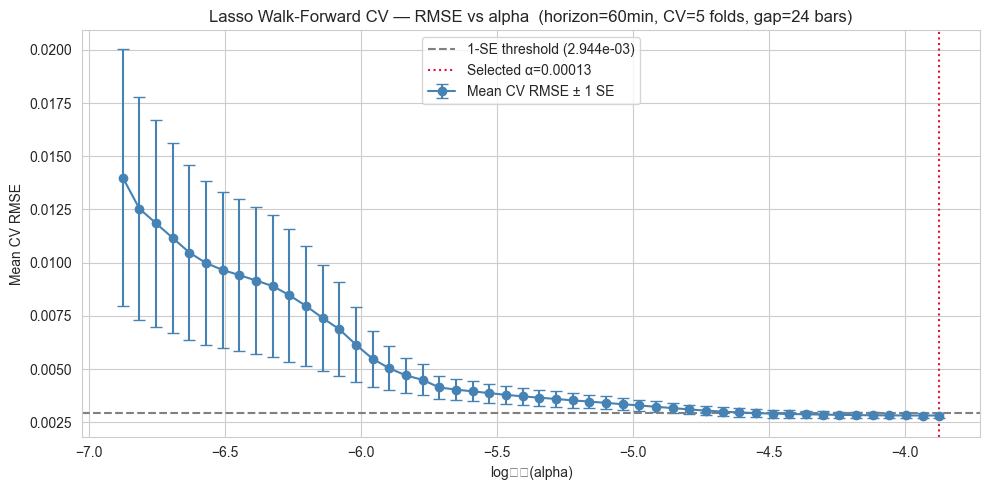

In [36]:

# %% ── CELL LASSO-2 : SELECT alpha (one-SE rule) + LINE PLOT ─────────────────
# One-standard-error rule for Lasso:
#   threshold = best_mean_rmse + SE(best)
#   Among all alphas whose mean RMSE ≤ threshold, choose the LARGEST alpha
#   (most regularised = fewest features = simplest model).
# sklearn does not expose the 1-SE rule natively; we compute it from
# lasso_cv_df reconstructed in LASSO-1 from LassoCV.mse_path_.

if lasso_cv_df.empty:
    raise RuntimeError("Lasso CV produced no results — check CV fold sizes.")

best_lasso_idx  = int(lasso_cv_df["mean_rmse"].idxmin())
best_lasso_rmse = lasso_cv_df.loc[best_lasso_idx, "mean_rmse"]
best_lasso_se   = (lasso_cv_df.loc[best_lasso_idx, "std_rmse"]
                   / np.sqrt(lasso_cv_df.loc[best_lasso_idx, "n_folds"]))
lasso_threshold = best_lasso_rmse + best_lasso_se

one_se_lasso    = lasso_cv_df[lasso_cv_df["mean_rmse"] <= lasso_threshold]
selected_alpha  = float(one_se_lasso["alpha"].max())   # largest alpha within 1 SE

print(f"Best mean RMSE           : {best_lasso_rmse:.6e}  "
      f"at alpha={lasso_cv_df.loc[best_lasso_idx, 'alpha']:.5g}")
print(f"SE at best               : {best_lasso_se:.2e}")
print(f"One-SE threshold         : {lasso_threshold:.6e}")
print(f"Selected alpha           : {selected_alpha:.5g}  (1-SE rule, max regularisation)")
print(f"LassoCV default alpha    : {_lasso_cv.alpha_:.5g}")

# ── Line plot: RMSE ± 1 SE vs log10(alpha) ────────────────────────────────────
se_bars_lasso = lasso_cv_df["std_rmse"] / np.sqrt(lasso_cv_df["n_folds"])
alphas_log    = np.log10(lasso_cv_df["alpha"].astype(float))

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    alphas_log,
    lasso_cv_df["mean_rmse"],
    yerr=se_bars_lasso,
    fmt="o-",
    capsize=4,
    label="Mean CV RMSE ± 1 SE",
    color="steelblue",
)
ax.axhline(lasso_threshold,
           color="grey", linestyle="--",
           label=f"1-SE threshold ({lasso_threshold:.3e})")
ax.axvline(np.log10(selected_alpha),
           color="crimson", linestyle=":",
           label=f"Selected α={selected_alpha:.2g}")
ax.set_xlabel("log₁₀(alpha)")
ax.set_ylabel("Mean CV RMSE")
ax.set_title(f"Lasso Walk-Forward CV — RMSE vs alpha  "
             f"(horizon={RETURN_HORIZON_MIN}min, CV={CV_N_SPLITS} folds, gap={CV_GAP_BARS} bars)")
ax.legend()
plt.tight_layout()
plt.show()



### Lasso — Full-sample fit and export

**⚠️ Descriptive artefact only — fit on the full sample. Do NOT use as direct input to backtests.
Modelling Baseline re-fits PLS/Lasso inside each walk-forward training window using the filtered raw panel below.**

The exported Lasso-selected feature CSV is saved for research inspection (e.g. to see which
Polymarket variables survive shrinkage) and not as a modelling input.


In [37]:

# %% ── CELL LASSO-3 : FIT FINAL LASSO ON FULL DATA + DESCRIPTIVE EXPORT ──────
# 1) Fit StandardScaler + Lasso(selected_alpha) on the full aligned dataset.
#    selected_alpha comes from the 1-SE rule in LASSO-2.
#    If it matches LassoCV's own alpha_ the fitted coefficients are reused;
#    otherwise a fresh Lasso is fit with the 1-SE alpha.
# 2) Identify columns with non-zero Lasso coefficients.
# 3) Export the ORIGINAL (pre-standardised) feature values for those columns.
#    Column names match the flat naming used in CELL DR-1 (var__slug_hash).
# The resulting CSV is a DESCRIPTIVE ARTEFACT (full-sample fit) — NOT for
# backtesting directly.  Modelling Baseline re-fits Lasso in-window.

if np.isclose(selected_alpha, _lasso_cv.alpha_):
    # Reuse the already-fitted LassoCV coefficients (alpha matches)
    nonzero_mask = _lasso_cv.coef_ != 0
    print(f"Using LassoCV coefficients (alpha matches 1-SE rule: {selected_alpha:.5g})")
else:
    # 1-SE alpha differs from LassoCV's minimum-CV alpha — refit with the scaler
    # already built by lasso_pipe (no data leakage: fitting on full sample is
    # intentional for this descriptive export)
    _X_scaled_lasso = lasso_pipe.named_steps["scaler"].transform(X_np)
    _lasso_1se = Lasso(alpha=selected_alpha, max_iter=10_000, random_state=RANDOM_STATE)
    _lasso_1se.fit(_X_scaled_lasso, y_np)
    nonzero_mask = _lasso_1se.coef_ != 0
    print(f"Refit Lasso with 1-SE alpha={selected_alpha:.5g} "
          f"(LassoCV default was {_lasso_cv.alpha_:.5g})")

nonzero_cols = X_flat.columns[nonzero_mask].tolist()
n_kept       = int(nonzero_mask.sum())
n_total      = X_flat.shape[1]

print(f"Lasso 1-SE selected alpha    : {selected_alpha:.5g}")
print(f"Non-zero coefficients        : {n_kept} / {n_total}  "
      f"({100 * n_kept / n_total:.1f}% retained)")

if n_kept == 0:
    print("\n⚠️  All coefficients are zero. Consider decreasing n_alphas or alpha range.")
else:
    print(f"\nRetained features (first 20 of {n_kept}):")
    _coefs_src = _lasso_cv if np.isclose(selected_alpha, _lasso_cv.alpha_) else _lasso_1se
    for c in nonzero_cols[:20]:
        _ci = X_flat.columns.get_loc(c)
        print(f"  {c:70s}  coef={_coefs_src.coef_[_ci]:+.4e}")
    if n_kept > 20:
        print(f"  … ({n_kept - 20} more features not shown)")

    # ── Export: original (unstandardised) values for non-zero columns ─────────
    df_lasso            = X_flat[nonzero_cols].copy()
    df_lasso.index.name = "scraped_at"

    lasso_csv_name = f"df_lasso_descriptive_{file_date}.csv"
    lasso_csv_path = Path(LOCAL_DATA_DIR) / lasso_csv_name
    df_lasso.to_csv(lasso_csv_path)
    print(f"\nLasso descriptive dataset saved  →  {lasso_csv_path}")
    print(f"  ⚠️  DESCRIPTIVE ONLY — fit on full sample. Do NOT use as direct modelling input.")
    print(f"Shape                            :  {df_lasso.shape}")
    print(f"File size                        :  {lasso_csv_path.stat().st_size / 1024:.1f} KB")



Using LassoCV coefficients (alpha matches 1-SE rule: 0.00013329)
Lasso 1-SE selected alpha    : 0.00013329
Non-zero coefficients        : 1 / 690  (0.1% retained)

Retained features (first 20 of 1):
  lastTradePrice__will_gold_gc_settle_over_4_800_on_the_final_trading_fa02eb  coef=+1.5482e-20

Lasso descriptive dataset saved  →  Data\df_lasso_descriptive_2026-05-07.csv
  ⚠️  DESCRIPTIVE ONLY — fit on full sample. Do NOT use as direct modelling input.
Shape                            :  (7171, 1)
File size                        :  175.3 KB


In [38]:

# %% ── EXPORT SUMMARY ─────────────────────────────────────────────────────────
print("=" * 70)
print("  FEATURE ENGINEERING EXPORT SUMMARY")
print("=" * 70)
print()
print(f"  PRIMARY (use in Modelling Baseline with FE_INPUT_MODE='raw_panel'):")
print(f"    {_filt_panel_name:<55}  shape={X_flat.shape}")
print()
print(f"  DESCRIPTIVE ONLY (do NOT use as direct backtest inputs):")
print(f"    {pls_csv_name:<55}  shape={df_pls.shape}")
if n_kept > 0:
    print(f"    {lasso_csv_name:<55}  shape={df_lasso.shape}")
else:
    print(f"    Lasso selected 0 features — no lasso CSV saved.")
print()
print(f"  F-stat market ranking:")
print(f"    fstat_market_ranking_{file_date}.csv")
print()
print("=" * 70)



  FEATURE ENGINEERING EXPORT SUMMARY

  PRIMARY (use in Modelling Baseline with FE_INPUT_MODE='raw_panel'):
    polymarket_panel_filtered_2026-05-07.csv                 shape=(7171, 690)

  DESCRIPTIVE ONLY (do NOT use as direct backtest inputs):
    df_pls_descriptive_2026-05-07.csv                        shape=(7171, 3)
    df_lasso_descriptive_2026-05-07.csv                      shape=(7171, 1)

  F-stat market ranking:
    fstat_market_ranking_2026-05-07.csv

